# Predicting 30-Day Hospital Readmission in Microsoft Fabric



**45-minute end-to-end client demo | Synthetic data only | No PHI**



This scenario shows how a care-management analytics team can identify encounters that may benefit from follow-up. The model output is for workflow prioritization and demonstration only; it is **not clinical advice**.

- **Persona**: Care management analytics team at a health system
- **Goal**: Predict 30-day readmission risk from patient encounters
- **Action**: Prioritize follow-up outreach for high-risk patients
- **Outcome**: Reduce readmissions, improve outcomes, avoid penalties




OneLake provides a single governed copy of the data for engineering, data science, BI, and conversational analytics.


### Initialize Fabric, MLflow, and model dependencies

**What this cell does:** 
- "This cell imports Spark for data engineering and scikit-learn (open source python library) for modeling."
- "MLflow is **built into Fabric**—no separate tracking server to manage."
- "We confirm a default Lakehouse is attached. If not, the notebook stops with a clear error."
- Notice: ***`notebookutils.runtime.context`*** gives us the Lakehouse name—this is Fabric's runtime API."

**Why it matters:** The notebook uses Spark for scalable preparation and Delta publication while registering endpoint-compatible scikit-learn model pipelines with MLflow.

**Fabric provides the managed Spark session, OneLake context, and integrated MLflow tracking, so the team can focus on the data science workflow rather than infrastructure setup.**

In [7]:
# Fabric setup - uses the pre-created Spark session and attached default Lakehouse
from datetime import datetime, timezone

import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.models import infer_signature
from pyspark.ml.feature import VectorAssembler
from pyspark.sql import functions as F
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

SEED = 42
ROW_COUNT = 5000
BRONZE_TABLE = "healthcare_encounters_bronze"
SILVER_TABLE = "healthcare_encounters_silver"
PREDICTIONS_TABLE = "healthcare_readmission_predictions"
SUMMARY_TABLE = "healthcare_readmission_summary"
REPORTING_TABLE = "healthcare_readmission_reporting"
MODEL_NAME = "healthcare_readmission_risk"
EXPERIMENT_NAME = "healthcare-readmission-demo"

default_lakehouse = notebookutils.runtime.context["defaultLakehouseName"]
if not default_lakehouse:
    raise RuntimeError("Attach a default Lakehouse to this notebook, then restart the Spark session.")

spark.conf.set("spark.sql.shuffle.partitions", "8")
sns.set_theme(style="whitegrid")

try:
    mlflow.set_experiment(EXPERIMENT_NAME)
except Exception:
    EXPERIMENT_NAME = f"healthcare-readmission-demo-{datetime.now(timezone.utc):%Y%m%d%H%M%S}"
    mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Lakehouse: {default_lakehouse} | Experiment: {EXPERIMENT_NAME}")
print("Data classification: fully synthetic; contains no PHI or real patient records.")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 21, Finished, Available, Finished, False)

Lakehouse: Healthcare_Readmission_LH | Experiment: healthcare-readmission-demo
Data classification: fully synthetic; contains no PHI or real patient records.


## 1. Ingest data into the Lakehouse using Spark



We generate reproducible synthetic encounters in Spark, land the raw records as Parquet under `Files/`, then ingest them into a managed bronze Delta table under `Tables/`.



This is the same bronze pattern used for files arriving from an EHR export or an integration pipeline, without exposing client data in the demo.

### Generate synthetic encounters and create the bronze layer



**What this cell does:** Creates 5,000 reproducible synthetic hospital encounters with Spark, introduces a small number of missing values, writes raw Parquet files to OneLake, and saves the ingested records as a managed bronze Delta table.



**Why it matters:** It demonstrates the complete ingestion path from raw files to a governed Lakehouse table without using real patient data.



The synthetic source can later be replaced by an EHR extract or data pipeline while the downstream Lakehouse pattern remains the same.

In [8]:
# Generate synthetic healthcare encounters entirely with Spark

base = spark.range(ROW_COUNT).withColumnRenamed("id", "row_id")



encounters = (

    base

    .withColumn("encounter_id", F.format_string("ENC%07d", F.col("row_id")))

    .withColumn("patient_id", F.format_string("PAT%06d", (F.col("row_id") % 3200)))

    .withColumn("age", (F.rand(SEED) * 78 + 18).cast("int"))

    .withColumn("gender", F.element_at(F.array(F.lit("Female"), F.lit("Male"), F.lit("Nonbinary")), (F.rand(SEED + 1) * 3 + 1).cast("int")))

    .withColumn("diagnosis_group", F.element_at(F.array(F.lit("Cardiac"), F.lit("Respiratory"), F.lit("Diabetes"), F.lit("Renal"), F.lit("Orthopedic")), (F.rand(SEED + 2) * 5 + 1).cast("int")))

    .withColumn("admission_type", F.element_at(F.array(F.lit("Emergency"), F.lit("Urgent"), F.lit("Elective")), (F.rand(SEED + 3) * 3 + 1).cast("int")))

    .withColumn("length_of_stay", F.greatest(F.lit(1), (F.rand(SEED + 4) * 14 + F.col("age") / 25).cast("int")))

    .withColumn("prior_admissions_12m", F.least(F.lit(8), (F.rand(SEED + 5) * 5).cast("int")))

    .withColumn("chronic_condition_count", F.least(F.lit(8), (F.rand(SEED + 6) * 4 + F.col("age") / 35).cast("int")))

    .withColumn("lab_risk_score", F.round(F.least(F.lit(100.0), F.rand(SEED + 7) * 65 + F.col("chronic_condition_count") * 5), 1))

    .withColumn("hemoglobin", F.round(F.rand(SEED + 8) * 8 + 9, 1))

    .withColumn("glucose", F.round(F.rand(SEED + 9) * 180 + 70, 0))

    .withColumn("medication_count", F.least(F.lit(25), (F.rand(SEED + 10) * 12 + F.col("chronic_condition_count") * 2).cast("int")))

    .withColumn("discharge_disposition", F.element_at(F.array(F.lit("Home"), F.lit("Home Health"), F.lit("Skilled Nursing"), F.lit("Rehab")), (F.rand(SEED + 11) * 4 + 1).cast("int")))

    .withColumn("payer_type", F.element_at(F.array(F.lit("Commercial"), F.lit("Medicare"), F.lit("Medicaid"), F.lit("Self-pay")), (F.rand(SEED + 12) * 4 + 1).cast("int")))

    .withColumn("admission_date", F.date_sub(F.current_date(), (F.rand(SEED + 13) * 730).cast("int")))

    .withColumn(

        "readmission_logit",

        F.lit(-3.7)

        + F.col("age") * 0.018

        + F.col("prior_admissions_12m") * 0.42

        + F.col("chronic_condition_count") * 0.24

        + F.col("length_of_stay") * 0.06

        + F.col("lab_risk_score") * 0.015

        + F.when(F.col("admission_type") == "Emergency", 0.35).otherwise(0.0)

        + F.when(F.col("discharge_disposition") == "Skilled Nursing", 0.40).otherwise(0.0)

    )

    .withColumn("readmission_probability", 1.0 / (1.0 + F.exp(-F.col("readmission_logit"))))

    .withColumn("readmitted_30d", (F.rand(SEED + 14) < F.col("readmission_probability")).cast("int"))

    .drop("row_id", "readmission_logit", "readmission_probability")

)



# Add a few deterministic missing values so cleaning is visible

encounters = (

    encounters

    .withColumn("lab_risk_score", F.when((F.substring("encounter_id", 4, 7).cast("int") % 97) == 0, None).otherwise(F.col("lab_risk_score")))

    .withColumn("payer_type", F.when((F.substring("encounter_id", 4, 7).cast("int") % 113) == 0, None).otherwise(F.col("payer_type")))

)



raw_path = "Files/healthcare_demo/raw/encounters"

encounters.write.mode("overwrite").parquet(raw_path)



bronze_df = spark.read.parquet(raw_path)

(

    bronze_df.write

    .format("delta")

    .mode("overwrite")

    .option("overwriteSchema", "true")

    .saveAsTable(BRONZE_TABLE)

)



print(f"Landed {bronze_df.count():,} rows at {raw_path} and in {BRONZE_TABLE}")

display(bronze_df.limit(10))

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 22, Finished, Available, Finished, False)

Landed 5,000 rows at Files/healthcare_demo/raw/encounters and in healthcare_encounters_bronze


SynapseWidget(Synapse.DataFrame, 130142ba-9209-432d-8843-2bac7218556d)

### Validate the bronze ingestion


> *"This cell runs lightweight assertions:"*
> - *"Row count = 5,000 (expected)"*
> - *"Encounter IDs are unique (no duplicates)"*
> - *"Required columns exist (patient_id, diagnosis_group, readmitted_30d)"*


**Why it matters:** Automated data-quality gates stop downstream analysis and training from silently using incomplete or duplicated data.



These lightweight assertions can evolve into production data-quality rules and pipeline monitoring. Data quality gates prevent downstream issues

In [9]:
# Bronze validation: fail early if ingestion did not produce the expected data

bronze_check = spark.table(BRONZE_TABLE)

assert bronze_check.count() == ROW_COUNT, "Unexpected bronze row count"

assert bronze_check.select("encounter_id").distinct().count() == ROW_COUNT, "Encounter IDs must be unique"

assert set(["patient_id", "diagnosis_group", "readmitted_30d"]).issubset(bronze_check.columns)

print("Bronze validation passed")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 23, Finished, Available, Finished, False)

Bronze validation passed


## 2. Explore and visualize patient data



Explore and visualize patient data. We'll use Spark for profiling and aggregation, then bring only small result sets to pandas for plotting.



Let's profile the encounter population to understand data quality, class balance, and clinical patterns.

### Profile the encounter population with Spark



**What this cell does:** Inspects the schema, calculates descriptive statistics and missing-value counts, measures class balance, and compares readmission rates across diagnosis and admission groups.



**Why it matters:** Profiling establishes whether the data is usable and reveals patterns that should inform cleaning, feature design, and model evaluation.



Spark performs these calculations at distributed scale while Fabric displays the results directly in the notebook.

"Notice we use `.cache()` to keep the DataFrame in memory for repeated analysis. Spark's lazy evaluation optimizes all these aggregations together

In [10]:
bronze_df = spark.table(BRONZE_TABLE).cache()

bronze_count = bronze_df.count()

print(f"Rows: {bronze_count:,} | Columns: {len(bronze_df.columns)}")

bronze_df.printSchema()



display(bronze_df.describe("age", "length_of_stay", "prior_admissions_12m", "lab_risk_score"))



missing_counts = bronze_df.select([

    F.sum(F.col(column).isNull().cast("int")).alias(column)

    for column in bronze_df.columns

])

display(missing_counts)



target_distribution = (

    bronze_df.groupBy("readmitted_30d")

    .agg(F.count("*").alias("encounters"))

    .withColumn("percent", F.round(F.col("encounters") / F.lit(bronze_count) * 100, 1))

    .orderBy("readmitted_30d")

)

display(target_distribution)



readmission_by_diagnosis = (

    bronze_df.groupBy("diagnosis_group")

    .agg(F.count("*").alias("encounters"), F.round(F.avg("readmitted_30d") * 100, 1).alias("readmission_rate_pct"))

    .orderBy(F.desc("readmission_rate_pct"))

)

display(readmission_by_diagnosis)



display(

    bronze_df.groupBy("admission_type")

    .agg(F.count("*").alias("encounters"), F.round(F.avg("readmitted_30d") * 100, 1).alias("readmission_rate_pct"))

    .orderBy(F.desc("readmission_rate_pct"))

)

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 24, Finished, Available, Finished, False)

Rows: 5,000 | Columns: 17
root
 |-- encounter_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- diagnosis_group: string (nullable = true)
 |-- admission_type: string (nullable = true)
 |-- length_of_stay: integer (nullable = true)
 |-- prior_admissions_12m: integer (nullable = true)
 |-- chronic_condition_count: integer (nullable = true)
 |-- lab_risk_score: double (nullable = true)
 |-- hemoglobin: double (nullable = true)
 |-- glucose: double (nullable = true)
 |-- medication_count: integer (nullable = true)
 |-- discharge_disposition: string (nullable = true)
 |-- payer_type: string (nullable = true)
 |-- admission_date: date (nullable = true)
 |-- readmitted_30d: integer (nullable = true)



SynapseWidget(Synapse.DataFrame, 71b72ba1-8500-482b-94b1-e4ea1c860727)

SynapseWidget(Synapse.DataFrame, 9fe5fac9-2dfb-4461-a3a9-9657bb0e8877)

SynapseWidget(Synapse.DataFrame, 6db8e9c3-acfe-475a-96ef-f234ac61962b)

SynapseWidget(Synapse.DataFrame, 978db2b0-1840-41eb-ad58-2a08b047fa81)

SynapseWidget(Synapse.DataFrame, 0645eb5c-464e-4be7-a24b-54ab3be8b0dd)

### Visualize the key risk patterns



**What this cell does:** Converts only small Spark aggregates to pandas and plots the readmission-label distribution, length-of-stay distribution, and relationship between prior admissions and readmission rate.



**Why it matters:** Visuals make class balance and important utilization patterns understandable before the model is introduced.


Large data remains in Spark; only presentation-sized summaries move to pandas, which is the appropriate boundary for notebook visualization.

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 25, Finished, Available, Finished, False)

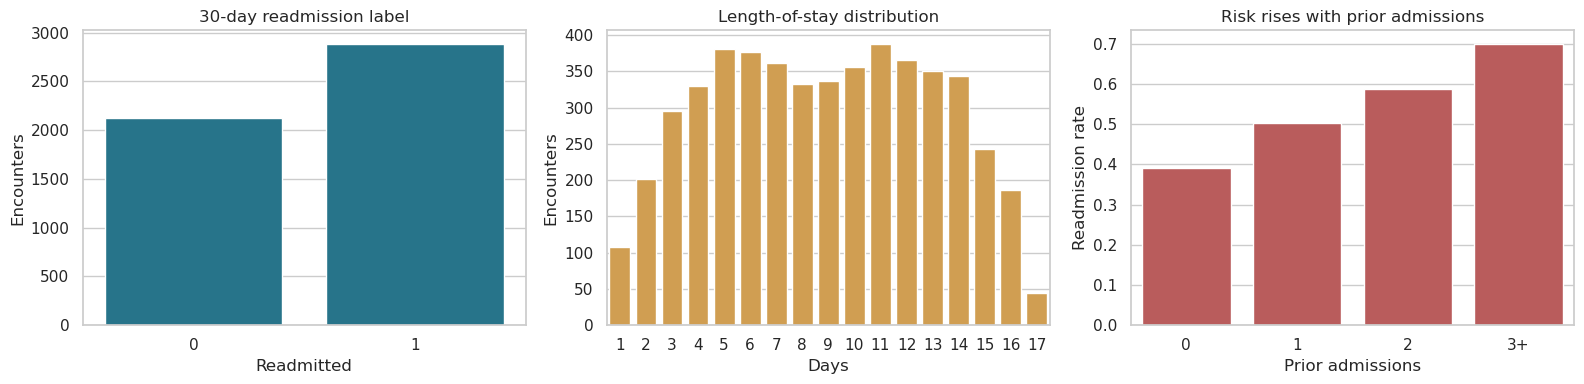

In [11]:
# Small Spark aggregates converted to pandas for notebook visuals

target_pd = target_distribution.toPandas()

los_pd = bronze_df.groupBy("length_of_stay").count().orderBy("length_of_stay").toPandas()

risk_pd = (

    bronze_df.withColumn("prior_admission_group", F.when(F.col("prior_admissions_12m") >= 3, "3+").otherwise(F.col("prior_admissions_12m").cast("string")))

    .groupBy("prior_admission_group")

    .agg(F.avg("readmitted_30d").alias("readmission_rate"))

    .orderBy("prior_admission_group")

    .toPandas()

)



fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=target_pd, x="readmitted_30d", y="encounters", ax=axes[0], color="#167D9A")

axes[0].set(title="30-day readmission label", xlabel="Readmitted", ylabel="Encounters")

sns.barplot(data=los_pd, x="length_of_stay", y="count", ax=axes[1], color="#E5A33D")

axes[1].set(title="Length-of-stay distribution", xlabel="Days", ylabel="Encounters")

sns.barplot(data=risk_pd, x="prior_admission_group", y="readmission_rate", ax=axes[2], color="#C94C4C")

axes[2].set(title="Risk rises with prior admissions", xlabel="Prior admissions", ylabel="Readmission rate")

plt.tight_layout()

plt.show()

### Explore relationships with correlation and heatmaps



**What this cell does:** Calculates a Pearson correlation matrix for numeric encounter features using Spark ML and creates a second heatmap showing observed readmission rates for each diagnosis and admission-type combination.



**Why it matters:** The correlation matrix helps identify related predictors and possible redundancy, while the operational heatmap highlights population segments that may warrant deeper analysis.



 Heatmaps quickly reveal associations and segment differences, but correlation does not establish causation or justify a clinical intervention. These results should guide questions, not clinical conclusions.

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 27, Finished, Available, Finished, False)

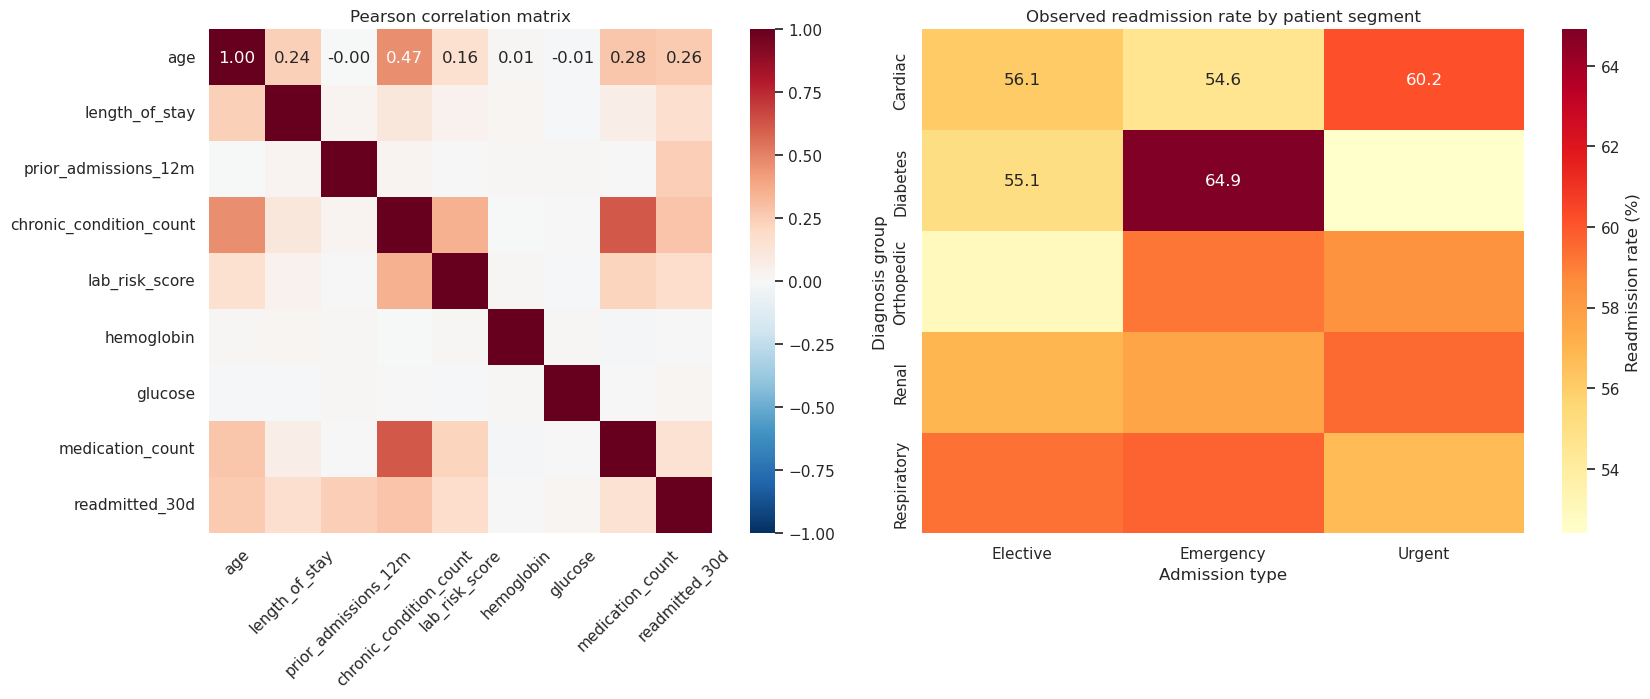

Interpretation reminder: correlation and segment differences show association, not causation.


In [12]:
from pyspark.ml.stat import Correlation



# Correlation is computed in Spark; only the small result matrix is collected for plotting.

correlation_columns = [

    "age", "length_of_stay", "prior_admissions_12m",

    "chronic_condition_count", "lab_risk_score", "hemoglobin",

    "glucose", "medication_count", "readmitted_30d",

]

correlation_input = (

    VectorAssembler(

        inputCols=correlation_columns,

        outputCol="correlation_features",

        handleInvalid="skip",

    )

    .transform(bronze_df.select(*correlation_columns))

    .select("correlation_features")

)

correlation_matrix = (

    Correlation.corr(correlation_input, "correlation_features", method="pearson")

    .first()[0]

    .toArray()

)



# This is a small grouped result: five diagnoses by three admission types.

segment_rates_pd = (

    bronze_df.groupBy("diagnosis_group", "admission_type")

    .agg(F.round(F.avg("readmitted_30d") * 100, 1).alias("readmission_rate_pct"))

    .toPandas()

)

segment_heatmap = segment_rates_pd.pivot(

    index="diagnosis_group",

    columns="admission_type",

    values="readmission_rate_pct",

)



fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(

    correlation_matrix,

    xticklabels=correlation_columns,

    yticklabels=correlation_columns,

    annot=True,

    fmt=".2f",

    cmap="RdBu_r",

    center=0,

    vmin=-1,

    vmax=1,

    square=True,

    ax=axes[0],

)

axes[0].set_title("Pearson correlation matrix")

axes[0].tick_params(axis="x", rotation=45)

axes[0].tick_params(axis="y", rotation=0)



sns.heatmap(

    segment_heatmap,

    annot=True,

    fmt=".1f",

    cmap="YlOrRd",

    cbar_kws={"label": "Readmission rate (%)"},

    ax=axes[1],

)

axes[1].set_title("Observed readmission rate by patient segment")

axes[1].set_xlabel("Admission type")

axes[1].set_ylabel("Diagnosis group")

axes[1].tick_params(axis="x", rotation=0)



plt.tight_layout()

plt.show()



print("Interpretation reminder: correlation and segment differences show association, not causation.")

## 3. Prepare and clean data with Data Wrangler and Spark



Begin with a visual Data Wrangler example for interactive profiling and transformation authoring, then run the equivalent reusable Spark pipeline to create the silver layer. Identifiers and the outcome label are deliberately excluded from the model feature vector to prevent leakage.



Feature examples:



- `age_band`: interpretable demographic segment

- `abnormal_lab_flag`: elevated lab-risk indicator

- `high_utilizer`: three or more prior admissions

- `medication_intensity`: low, medium, or high medication count

- `comorbidity_count`: renamed count of chronic conditions

### Explore cleaning interactively with Data Wrangler



**What this cell does:** Creates a focused Spark DataFrame from the Bronze table that can be opened directly in Fabric Data Wrangler for visual profiling and transformation authoring.



**Why it matters:** Data Wrangler helps analysts inspect distributions, missing values, and column quality while generating reusable PySpark code for selected cleaning steps.



A visual low-code experience and notebook code are not separate paths: Data Wrangler accelerates exploration, then writes the generated transformation code back into the notebook for review and reuse.

In [6]:
# Keep the Data Wrangler demo focused on columns with useful cleaning examples.

wrangler_input_df = (

    spark.table(BRONZE_TABLE)

    .select(

        "encounter_id",

        "age",

        "length_of_stay",

        "prior_admissions_12m",

        "lab_risk_score",

        "payer_type",

        "diagnosis_group",

        "readmitted_30d",

    )

)



print(f"Data Wrangler input rows: {wrangler_input_df.count():,}")

display(wrangler_input_df.limit(20))

StatementMeta(, 80aec0cc-b67d-47c3-b190-8c1e0403ddba, 12, Finished, Available, Finished, False)

Data Wrangler input rows: 5,000


SynapseWidget(Synapse.DataFrame, c6ef28d5-ca88-498d-91e6-7c64368094c8)

In [7]:
# Code generated by Data Wrangler for PySpark DataFrame

from pyspark.sql.functions import col

def clean_data(wrangler_input_df):
    # Replace missing values with "Unknown" in column: 'payer_type'
    wrangler_input_df = wrangler_input_df.fillna(value="Unknown", subset=['payer_type'])
    # Replace missing values with 50 in column: 'lab_risk_score'
    wrangler_input_df = wrangler_input_df.fillna(value=50, subset=['lab_risk_score'])
    # LLM translation result for custom operation
    wrangler_input_df = wrangler_input_df.filter((col('age') >= 18) & (col('age') <= 35))
    return wrangler_input_df

wrangler_input_df_clean = clean_data(wrangler_input_df)
display(wrangler_input_df_clean)

StatementMeta(, 80aec0cc-b67d-47c3-b190-8c1e0403ddba, 37, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 181d59e0-310a-43e1-8f3d-fa588debe3a3)

#### Data Wrangler live-demo steps



1. Run the cell above so `wrangler_input_df` is available in the Spark session.

2. From the Fabric notebook ribbon, open **Data Wrangler** and select `wrangler_input_df`.

3. Use the summary/profile view to point out column types, distributions, and missing values.

4. Add these transformations in the visual interface:

   - Remove duplicate rows using `encounter_id`.

   - Filter `age` to values from 18 through 100.

   - Replace missing `lab_risk_score` with `50.0`.

   - Replace missing `payer_type` with `Unknown`.

   - Rename `prior_admissions_12m` to `prior_admissions_last_year` as a quick demonstration, then remove that rename before generating the final code so downstream names remain unchanged.

5. Review the generated PySpark preview after each operation.

6. Choose **Add code to notebook** to insert the generated transformation function or cell.



> **Demo note:** The next notebook cell remains the authoritative silver-layer pipeline. The Data Wrangler exercise demonstrates visual authoring; do not overwrite `SILVER_TABLE` from the temporary generated cell during the live demo.



> **Expected code concepts:** `dropDuplicates`, `filter`, `fillna`, and `withColumnRenamed`. This makes it easy to connect each visual action to its Spark implementation.


### Clean the data and create reusable business features



**What this cell does:** Removes duplicate encounters, enforces plausible ranges, fills missing values, creates interpretable risk features, and saves the curated result as the silver Delta table.



**Why it matters:** Consistent cleaning and feature definitions make the analytical dataset reusable across model training, reporting, and future scoring runs.



The silver layer preserves understandable business columns while adding model-ready signals such as age band and high-utilizer status.

In [13]:
clean_df = (

    spark.table(BRONZE_TABLE)

    .dropDuplicates(["encounter_id"])

    .filter(F.col("age").between(18, 100))

    .withColumn("length_of_stay", F.least(F.greatest(F.col("length_of_stay"), F.lit(1)), F.lit(60)))

    .withColumn("prior_admissions_12m", F.least(F.greatest(F.col("prior_admissions_12m"), F.lit(0)), F.lit(20)))

    .fillna({"lab_risk_score": 50.0, "payer_type": "Unknown"})

    .withColumn(

        "age_band",

        F.when(F.col("age") < 40, "18-39")

        .when(F.col("age") < 55, "40-54")

        .when(F.col("age") < 70, "55-69")

        .otherwise("70+")

    )

    .withColumn("abnormal_lab_flag", (F.col("lab_risk_score") >= 65).cast("int"))

    .withColumn("high_utilizer", (F.col("prior_admissions_12m") >= 3).cast("int"))

    .withColumn(

        "medication_intensity",

        F.when(F.col("medication_count") < 6, "Low")

        .when(F.col("medication_count") < 12, "Medium")

        .otherwise("High")

    )

    .withColumnRenamed("chronic_condition_count", "comorbidity_count")

)



(

    clean_df.write

    .format("delta")

    .mode("overwrite")

    .option("overwriteSchema", "true")

    .saveAsTable(SILVER_TABLE)

)



silver_df = spark.table(SILVER_TABLE).cache()

display(silver_df.select("encounter_id", "age_band", "high_utilizer", "medication_intensity", "readmitted_30d").limit(10))

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 29, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 8e25f54a-4b82-453e-9618-5e8782c46b36)

### Validate the curated silver layer



**What this cell does:** Confirms that cleaning retained all expected records, removed the targeted nulls, kept ages within the valid range, and created every engineered feature.



**Why it matters:** The model should train only after the curated dataset passes explicit quality and schema checks.



Validation makes the transformation auditable and protects the model from unexpected upstream data changes.

In [14]:
# Silver validation

assert silver_df.count() == ROW_COUNT, "Cleaning unexpectedly changed the row count"

assert silver_df.filter(F.col("lab_risk_score").isNull() | F.col("payer_type").isNull()).count() == 0

assert silver_df.filter(~F.col("age").between(18, 100)).count() == 0

assert {"age_band", "abnormal_lab_flag", "high_utilizer", "medication_intensity", "comorbidity_count"}.issubset(silver_df.columns)

print("Silver validation passed")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 30, Finished, Available, Finished, False)

Silver validation passed


## 4. Train and evaluate three machine learning models

Train and compare three different classification algorithms:
1. **Logistic Regression**: Interpretable baseline with linear decision boundaries
2. **Random Forest**: Ensemble method that captures non-linear relationships
3. **XGBoost**: Gradient boosting algorithm known for high performance

All models use the same preprocessing pipeline and train/test split for fair comparison. Each complete pipeline is logged to MLflow and registered as a version of `healthcare_readmission_risk`.

MLflow captures lineage, parameters, metrics, and model versions across algorithm families. The registered models can be compared and governed independently from this notebook.

## Prepare training data and preprocessing pipeline

**What this cell does:** Defines feature columns, creates train/test split, and builds the preprocessing pipeline with categorical encoding and numeric scaling that will be shared across all three models.

- *"Loads the silver table and converts to pandas (5,000 rows fit in memory for this demo)"*
- *"Splits 70/30 into training and test sets with stratification to preserve class balance"*

**Why it matters:** Using a consistent preprocessing pipeline and data split ensures fair model comparison and makes the results reproducible.

The preprocessing pipeline handles missing values, encodes categorical features, and scales numeric features automatically, making the model deployable without manual data preparation.

In [15]:
# Define feature columns for modeling
categorical_columns = [
    "gender", "diagnosis_group", "admission_type", "discharge_disposition",
    "payer_type", "age_band", "medication_intensity",
]
numeric_columns = [
    "age", "length_of_stay", "prior_admissions_12m", "comorbidity_count",
    "lab_risk_score", "hemoglobin", "glucose", "medication_count",
    "abnormal_lab_flag", "high_utilizer",
]
model_features = categorical_columns + numeric_columns

# Convert to pandas for scikit-learn/XGBoost training
model_pdf = silver_df.select(*model_features, "readmitted_30d").toPandas()

# Create stratified train/test split
train_x, test_x, train_y, test_y = train_test_split(
    model_pdf[model_features],
    model_pdf["readmitted_30d"].astype(int),
    test_size=0.2,
    random_state=SEED,
    stratify=model_pdf["readmitted_30d"],
)

print(f"Training rows: {len(train_x):,} | Test rows: {len(test_x):,}")
print(f"Features: {len(model_features)} ({len(categorical_columns)} categorical + {len(numeric_columns)} numeric)")

# Build preprocessing pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_transformer, categorical_columns),
    ("numeric", numeric_transformer, numeric_columns),
])

# Evaluation function
def evaluate_predictions(actual, predicted, probabilities):
    return {
        "auc": roc_auc_score(actual, probabilities),
        "accuracy": accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, average="weighted", zero_division=0),
        "recall": recall_score(actual, predicted, average="weighted", zero_division=0),
        "f1": f1_score(actual, predicted, average="weighted", zero_division=0),
    }

print("\nPreprocessing pipeline ready for model training.")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 31, Finished, Available, Finished, False)

Training rows: 4,000 | Test rows: 1,000
Features: 17 (7 categorical + 10 numeric)

Preprocessing pipeline ready for model training.


### Train and evaluate all three models

**What this cell does:** Trains Logistic Regression, Random Forest, and XGBoost classifiers with the same preprocessing pipeline and data split, evaluates each with five metrics, and registers all three with MLflow signatures.

**Why it matters:** Training multiple algorithms allows comparison of different modeling approaches - linear vs. ensemble vs. gradient boosting - to select the best performer for deployment.

Fabric and MLflow provide governed experiment tracking across algorithm families. Each model is deployment-ready with its preprocessing pipeline, enabling fair comparison of accuracy, interpretability, and latency.

In [16]:
# Define all necessary components for training
# Clear all Spark caches and refresh the silver table
spark.catalog.clearCache()
spark.sql(f"REFRESH TABLE {SILVER_TABLE}")
silver_df = spark.table(SILVER_TABLE).cache()

# Feature columns
categorical_columns = [
    "gender", "diagnosis_group", "admission_type", "discharge_disposition",
    "payer_type", "age_band", "medication_intensity",
]
numeric_columns = [
    "age", "length_of_stay", "prior_admissions_12m", "comorbidity_count",
    "lab_risk_score", "hemoglobin", "glucose", "medication_count",
    "abnormal_lab_flag", "high_utilizer",
]
model_features = categorical_columns + numeric_columns

# Convert to pandas for training
model_pdf = silver_df.select(*model_features, "readmitted_30d").toPandas()

# Create train/test split
train_x, test_x, train_y, test_y = train_test_split(
    model_pdf[model_features],
    model_pdf["readmitted_30d"].astype(int),
    test_size=0.2,
    random_state=SEED,
    stratify=model_pdf["readmitted_30d"],
)

# Build preprocessing pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
preprocessor = ColumnTransformer([
    ("categorical", categorical_transformer, categorical_columns),
    ("numeric", numeric_transformer, numeric_columns),
])

# Evaluation function
def evaluate_predictions(actual, predicted, probabilities):
    return {
        "auc": roc_auc_score(actual, probabilities),
        "accuracy": accuracy_score(actual, predicted),
        "precision": precision_score(actual, predicted, average="weighted", zero_division=0),
        "recall": recall_score(actual, predicted, average="weighted", zero_division=0),
        "f1": f1_score(actual, predicted, average="weighted", zero_division=0),
    }

print(f"Training setup complete: {len(train_x):,} training rows, {len(test_x):,} test rows")

# Dictionary to store models and results
model_results = {}

# ==================== Model 1: Logistic Regression ====================
print("\n" + "=" * 70)
print("Training Model 1: Logistic Regression")
print("=" * 70)

logistic_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(max_iter=500, random_state=SEED)),
])

with mlflow.start_run(run_name="logistic-regression") as lr_run:
    logistic_model.fit(train_x, train_y)
    lr_predictions = logistic_model.predict(test_x)
    lr_probabilities = logistic_model.predict_proba(test_x)[:, 1]
    lr_metrics = evaluate_predictions(test_y, lr_predictions, lr_probabilities)
    lr_signature = infer_signature(test_x, lr_predictions)
    
    mlflow.log_params({
        "algorithm": "Logistic Regression",
        "max_iter": 500,
        "penalty": "l2",
        "solver": "lbfgs",
    })
    mlflow.log_metrics(lr_metrics)
    lr_model_info = mlflow.sklearn.log_model(
        logistic_model,
        "model",
        signature=lr_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    lr_run_id = lr_run.info.run_id

model_results["Logistic Regression"] = {
    "model": logistic_model,
    "predictions": lr_predictions,
    "probabilities": lr_probabilities,
    "metrics": lr_metrics,
    "run_id": lr_run_id,
}

print(f"✓ Logistic Regression trained | Run ID: {lr_run_id}")
print(f"  AUC: {lr_metrics['auc']:.4f} | Accuracy: {lr_metrics['accuracy']:.4f} | F1: {lr_metrics['f1']:.4f}\n")


# ==================== Model 2: Random Forest ====================
print("=" * 70)
print("Training Model 2: Random Forest")
print("=" * 70)

random_forest_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=SEED,
        n_jobs=-1,
    )),
])

with mlflow.start_run(run_name="random-forest") as rf_run:
    random_forest_model.fit(train_x, train_y)
    rf_predictions = random_forest_model.predict(test_x)
    rf_probabilities = random_forest_model.predict_proba(test_x)[:, 1]
    rf_metrics = evaluate_predictions(test_y, rf_predictions, rf_probabilities)
    rf_signature = infer_signature(test_x, rf_predictions)
    
    mlflow.log_params({
        "algorithm": "Random Forest",
        "n_estimators": 100,
        "max_depth": 8,
        "min_samples_split": 10,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
    })
    mlflow.log_metrics(rf_metrics)
    rf_model_info = mlflow.sklearn.log_model(
        random_forest_model,
        "model",
        signature=rf_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    rf_run_id = rf_run.info.run_id

model_results["Random Forest"] = {
    "model": random_forest_model,
    "predictions": rf_predictions,
    "probabilities": rf_probabilities,
    "metrics": rf_metrics,
    "run_id": rf_run_id,
}

print(f"✓ Random Forest trained | Run ID: {rf_run_id}")
print(f"  AUC: {rf_metrics['auc']:.4f} | Accuracy: {rf_metrics['accuracy']:.4f} | F1: {rf_metrics['f1']:.4f}\n")


# ==================== Model 3: XGBoost ====================
print("=" * 70)
print("Training Model 3: XGBoost")
print("=" * 70)

xgboost_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=SEED,
        eval_metric='logloss',
        use_label_encoder=False,
    )),
])

with mlflow.start_run(run_name="xgboost") as xgb_run:
    xgboost_model.fit(train_x, train_y)
    xgb_predictions = xgboost_model.predict(test_x)
    xgb_probabilities = xgboost_model.predict_proba(test_x)[:, 1]
    xgb_metrics = evaluate_predictions(test_y, xgb_predictions, xgb_probabilities)
    xgb_signature = infer_signature(test_x, xgb_predictions)
    
    mlflow.log_params({
        "algorithm": "XGBoost",
        "n_estimators": 100,
        "max_depth": 6,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    })
    mlflow.log_metrics(xgb_metrics)
    xgb_model_info = mlflow.sklearn.log_model(
        xgboost_model,
        "model",
        signature=xgb_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    xgb_run_id = xgb_run.info.run_id

model_results["XGBoost"] = {
    "model": xgboost_model,
    "predictions": xgb_predictions,
    "probabilities": xgb_probabilities,
    "metrics": xgb_metrics,
    "run_id": xgb_run_id,
}

print(f"✓ XGBoost trained | Run ID: {xgb_run_id}")
print(f"  AUC: {xgb_metrics['auc']:.4f} | Accuracy: {xgb_metrics['accuracy']:.4f} | F1: {xgb_metrics['f1']:.4f}\n")


# ==================== Model Comparison ====================
print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

comparison_rows = []
for model_name, result in model_results.items():
    metrics = result["metrics"]
    comparison_rows.append({
        "Model": model_name,
        "AUC": float(metrics["auc"]),
        "Accuracy": float(metrics["accuracy"]),
        "Precision": float(metrics["precision"]),
        "Recall": float(metrics["recall"]),
        "F1": float(metrics["f1"]),
    })

comparison_df = spark.createDataFrame(comparison_rows).orderBy(F.desc("AUC"))
display(comparison_df)

# Identify best model
best_model_name = max(model_results.keys(), key=lambda k: model_results[k]["metrics"]["auc"])
best_model_info = model_results[best_model_name]
print(f"\n🏆 Best Model by AUC: {best_model_name}")
print(f"   AUC: {best_model_info['metrics']['auc']:.4f}")
print(f"   Run ID: {best_model_info['run_id']}")
print(f"\n✓ All three models registered under name: {MODEL_NAME}")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 32, Finished, Available, Finished, False)

Training setup complete: 4,000 training rows, 1,000 test rows

Training Model 1: Logistic Regression


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distuti

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026-08-03:16:13:32,613 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"702367ff-3cfe-4d01-9cad-7f13dab1690b","errorCode":"ItemDisplayNameAlreadyInUse","message

✓ Random Forest trained | Run ID: 15707ddb-b2e5-4882-9423-0657c717c8be
  AUC: 0.6994 | Accuracy: 0.6490 | F1: 0.6422

Training Model 3: XGBoost


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026-08-03:16:13:40,164 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"4b4e64cd-e081-42fe-a5e5-6c942a632a5c","errorCode":"ItemDisplayNameAlreadyInUse","message

✓ XGBoost trained | Run ID: f88127ed-d10e-4fe3-b2d2-20f999181f5f
  AUC: 0.6881 | Accuracy: 0.6360 | F1: 0.6314


MODEL COMPARISON SUMMARY


SynapseWidget(Synapse.DataFrame, ade73a35-ef0a-4549-a72f-c4653cc75a7f)


🏆 Best Model by AUC: Logistic Regression
   AUC: 0.7267
   Run ID: 96fe8715-a88c-4eca-b5fe-2ea12c086797

✓ All three models registered under name: healthcare_readmission_risk


### Visualize model performance comparison

**What this cell does:** Creates visual comparisons of the three models including metric bar charts, confusion matrices, and ROC curves to help identify the best performer.

**Why it matters:** Visual comparison makes it easier to understand model tradeoffs and communicate results to stakeholders who may not be familiar with raw metrics.

Different models excel at different aspects - Logistic Regression is interpretable, Random Forest captures interactions, and XGBoost often achieves the best overall performance.

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 34, Finished, Available, Finished, False)

/tmp/ipykernel_6673/1787426036.py:84: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(auc_data["Model"], rotation=15, ha='right')


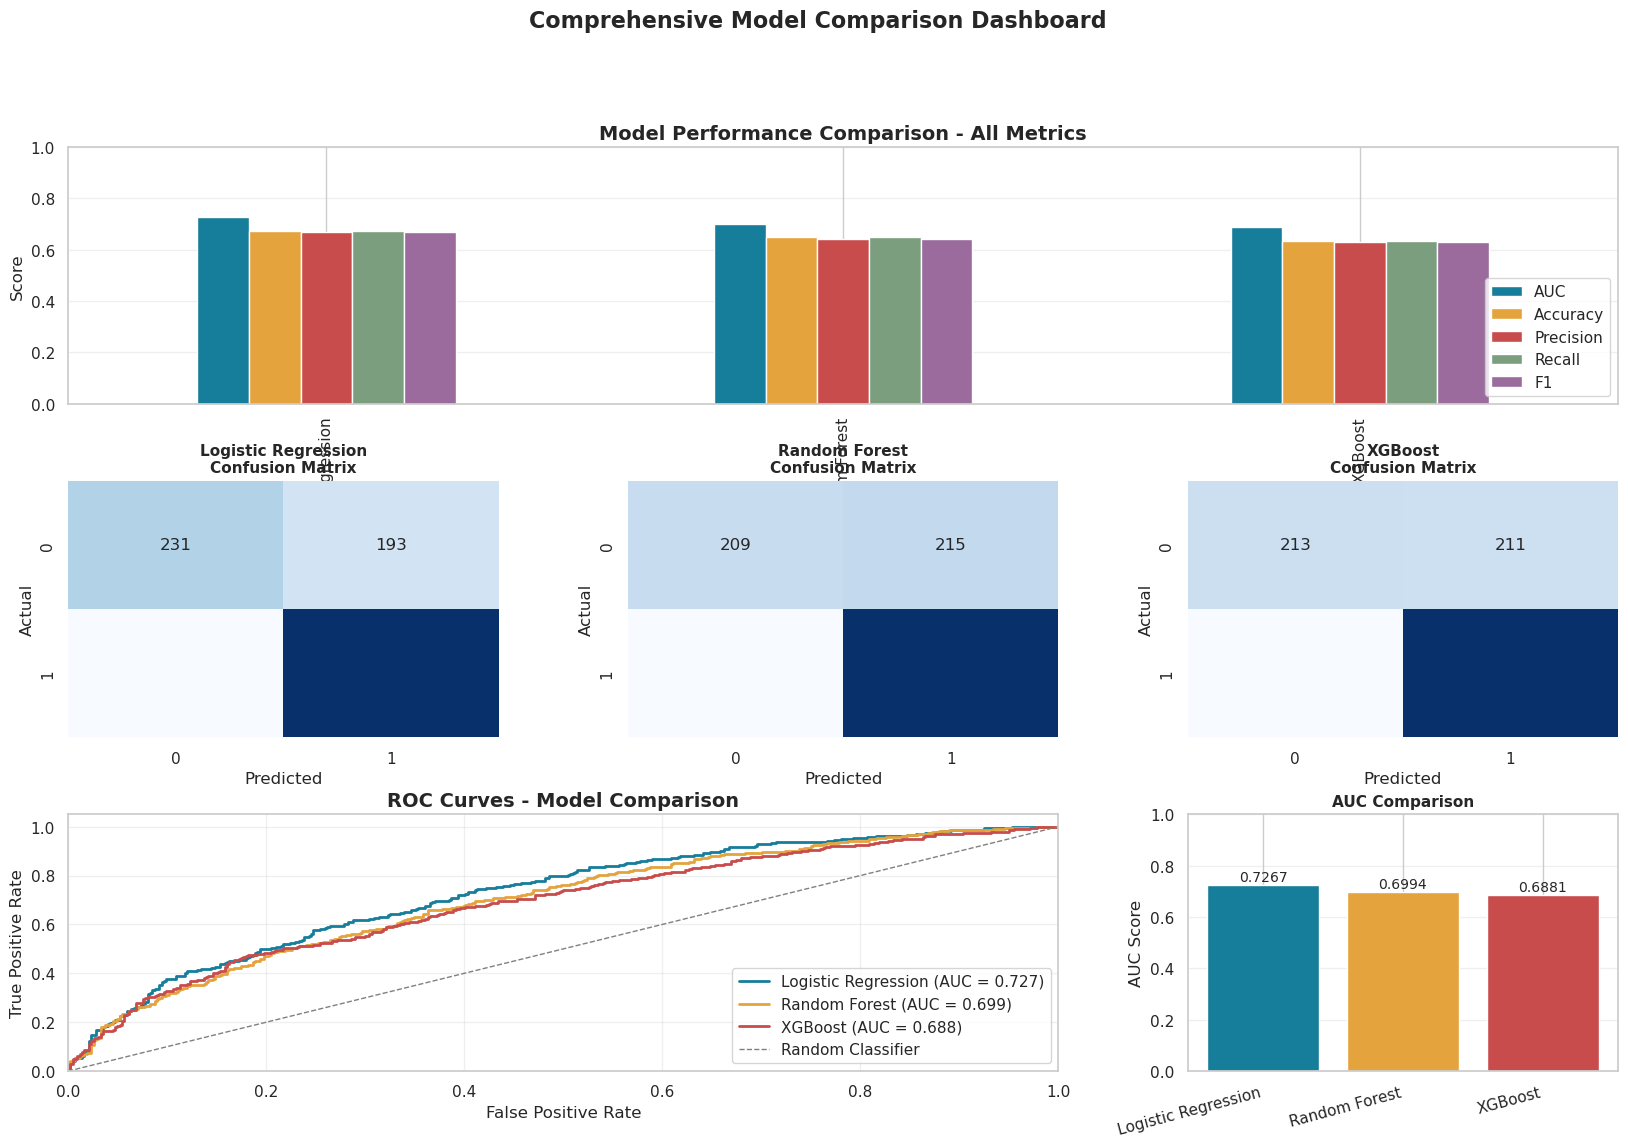


PERFORMANCE INSIGHTS

Logistic Regression:
  • AUC:       0.7267
  • Accuracy:  0.6720
  • Precision: 0.6683
  • Recall:    0.6720
  • F1 Score:  0.6678

Random Forest:
  • AUC:       0.6994
  • Accuracy:  0.6490
  • Precision: 0.6438
  • Recall:    0.6490
  • F1 Score:  0.6422

XGBoost:
  • AUC:       0.6881
  • Accuracy:  0.6360
  • Precision: 0.6311
  • Recall:    0.6360
  • F1 Score:  0.6314


In [17]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import pandas as pd  # Ensure pandas is available as pd

# Ensure model_results is available; if not, recompute it from the trained models.
# This makes the cell more robust when run independently, assuming the training cell has executed.
try:
    model_results
except NameError:
    raise NameError(
        "model_results is not defined. Please run the training cell that builds "
        "'model_results' (the 'Train and evaluate all three models' cell) before "
        "running this visualization cell."
    )

# Prepare data for visualizations
comparison_rows = []
for model_name, result in model_results.items():
    metrics = result["metrics"]
    comparison_rows.append({
        "Model": model_name,
        "AUC": float(metrics["auc"]),
        "Accuracy": float(metrics["accuracy"]),
        "Precision": float(metrics["precision"]),
        "Recall": float(metrics["recall"]),
        "F1": float(metrics["f1"]),
    })

metrics_comparison = pd.DataFrame(comparison_rows).set_index("Model")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Metrics comparison bar chart
ax1 = fig.add_subplot(gs[0, :])
metrics_comparison[["AUC", "Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", ax=ax1, color=["#167D9A", "#E5A33D", "#C94C4C", "#7A9E7E", "#9B6B9E"]
)
ax1.set_title("Model Performance Comparison - All Metrics", fontsize=14, fontweight="bold")
ax1.set_ylabel("Score")
ax1.set_xlabel("Model")
ax1.set_ylim([0, 1])
ax1.legend(loc="lower right")
ax1.grid(axis='y', alpha=0.3)

# 2-4. Confusion matrices for each model
model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
for idx, model_name in enumerate(model_names):
    ax = fig.add_subplot(gs[1, idx])
    cm = confusion_matrix(test_y, model_results[model_name]["predictions"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"{model_name}\nConfusion Matrix", fontsize=11, fontweight="bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

# 5. ROC Curves comparison
ax5 = fig.add_subplot(gs[2, :2])
colors = ["#167D9A", "#E5A33D", "#C94C4C"]
for idx, model_name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(test_y, model_results[model_name]["probabilities"])
    roc_auc = auc(fpr, tpr)
    ax5.plot(fpr, tpr, color=colors[idx], lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

ax5.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight="bold")
ax5.legend(loc="lower right")
ax5.grid(alpha=0.3)

# 6. AUC comparison bar chart
ax6 = fig.add_subplot(gs[2, 2])
auc_data = pd.DataFrame([
    {"Model": model_name, "AUC": model_results[model_name]["metrics"]["auc"]}
    for model_name in model_names
])
bars = ax6.bar(auc_data["Model"], auc_data["AUC"], color=colors)
ax6.set_title("AUC Comparison", fontsize=11, fontweight="bold")
ax6.set_ylabel("AUC Score")
ax6.set_ylim([0, 1])
ax6.set_xticklabels(auc_data["Model"], rotation=15, ha='right')
ax6.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle("Comprehensive Model Comparison Dashboard", 
             fontsize=16, fontweight="bold", y=0.995)
plt.show()

print("\n" + "=" * 70)
print("PERFORMANCE INSIGHTS")
print("=" * 70)
for model_name in model_names:
    metrics = model_results[model_name]["metrics"]
    print(f"\n{model_name}:")
    print(f"  • AUC:       {metrics['auc']:.4f}")
    print(f"  • Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  • Precision: {metrics['precision']:.4f}")
    print(f"  • Recall:    {metrics['recall']:.4f}")
    print(f"  • F1 Score:  {metrics['f1']:.4f}")

## 5. Hyperparameter Tuning for All Three Models

Now that we've established baseline performance, let's tune each model's hyperparameters using GridSearchCV with 3-fold cross-validation.

**Tuning Strategy:**
- **Logistic Regression**: Regularization strength (C) and penalty type (L1/L2/ElasticNet)
- **Random Forest**: Tree depth, number of estimators, and splitting criteria
- **XGBoost**: Learning rate, max depth, and regularization parameters

Each model uses the same preprocessing pipeline and train/test split to ensure fair comparison.

Hyperparameter tuning can significantly improve model performance. MLflow tracks all parameter combinations and selects the best by cross-validation AUC.

In [18]:
print("=" * 80)
print("HYPERPARAMETER TUNING - ALL THREE MODELS")
print("=" * 80)
print(f"Training data: {len(train_x):,} rows | Test data: {len(test_x):,} rows")
print("Cross-validation: 3-fold stratified")
print("Optimization metric: ROC AUC\n")

# Dictionary to store tuned models and results
tuned_model_results = {}

# ==================== Tune Model 1: Logistic Regression ====================
print("=" * 80)
print("TUNING MODEL 1: Logistic Regression")
print("=" * 80)
print("Testing 12 parameter combinations...")

lr_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(max_iter=500, random_state=SEED, solver="saga")),
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0],
    "classifier__penalty": ["l1", "l2", "elasticnet"],
    "classifier__l1_ratio": [0.5],  # Only used for elasticnet
}

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

with mlflow.start_run(run_name="logistic-regression-tuned") as lr_tuned_run:
    lr_grid_search.fit(train_x, train_y)
    lr_tuned_model = lr_grid_search.best_estimator_
    lr_tuned_predictions = lr_tuned_model.predict(test_x)
    lr_tuned_probabilities = lr_tuned_model.predict_proba(test_x)[:, 1]
    lr_tuned_metrics = evaluate_predictions(test_y, lr_tuned_predictions, lr_tuned_probabilities)
    
    mlflow.log_params({
        "algorithm": "Logistic Regression (Tuned)",
        **{k.replace("classifier__", ""): v for k, v in lr_grid_search.best_params_.items()},
        "cv_folds": 3,
        "cv_best_score": lr_grid_search.best_score_,
    })
    mlflow.log_metrics(lr_tuned_metrics)
    
    lr_tuned_signature = infer_signature(test_x, lr_tuned_predictions)
    mlflow.sklearn.log_model(
        lr_tuned_model,
        "model",
        signature=lr_tuned_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    lr_tuned_run_id = lr_tuned_run.info.run_id

tuned_model_results["Logistic Regression"] = {
    "baseline": model_results["Logistic Regression"]["metrics"],
    "tuned": lr_tuned_metrics,
    "best_params": lr_grid_search.best_params_,
    "cv_score": lr_grid_search.best_score_,
    "run_id": lr_tuned_run_id,
}

print(f"✓ Best parameters: {lr_grid_search.best_params_}")
print(f"✓ CV AUC: {lr_grid_search.best_score_:.4f}")
print(f"✓ Test AUC: {lr_tuned_metrics['auc']:.4f} (baseline: {model_results['Logistic Regression']['metrics']['auc']:.4f})")
print(f"✓ Improvement: {(lr_tuned_metrics['auc'] - model_results['Logistic Regression']['metrics']['auc']):.4f}\n")


# ==================== Tune Model 2: Random Forest ====================
print("=" * 80)
print("TUNING MODEL 2: Random Forest")
print("=" * 80)
print("Testing 24 parameter combinations...")

rf_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

rf_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [6, 8, 10],
    "classifier__min_samples_split": [5, 10],
    "classifier__min_samples_leaf": [2, 5],
}

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

with mlflow.start_run(run_name="random-forest-tuned") as rf_tuned_run:
    rf_grid_search.fit(train_x, train_y)
    rf_tuned_model = rf_grid_search.best_estimator_
    rf_tuned_predictions = rf_tuned_model.predict(test_x)
    rf_tuned_probabilities = rf_tuned_model.predict_proba(test_x)[:, 1]
    rf_tuned_metrics = evaluate_predictions(test_y, rf_tuned_predictions, rf_tuned_probabilities)
    
    mlflow.log_params({
        "algorithm": "Random Forest (Tuned)",
        **{k.replace("classifier__", ""): v for k, v in rf_grid_search.best_params_.items()},
        "cv_folds": 3,
        "cv_best_score": rf_grid_search.best_score_,
    })
    mlflow.log_metrics(rf_tuned_metrics)
    
    rf_tuned_signature = infer_signature(test_x, rf_tuned_predictions)
    mlflow.sklearn.log_model(
        rf_tuned_model,
        "model",
        signature=rf_tuned_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    rf_tuned_run_id = rf_tuned_run.info.run_id

tuned_model_results["Random Forest"] = {
    "baseline": model_results["Random Forest"]["metrics"],
    "tuned": rf_tuned_metrics,
    "best_params": rf_grid_search.best_params_,
    "cv_score": rf_grid_search.best_score_,
    "run_id": rf_tuned_run_id,
}

print(f"✓ Best parameters: {rf_grid_search.best_params_}")
print(f"✓ CV AUC: {rf_grid_search.best_score_:.4f}")
print(f"✓ Test AUC: {rf_tuned_metrics['auc']:.4f} (baseline: {model_results['Random Forest']['metrics']['auc']:.4f})")
print(f"✓ Improvement: {(rf_tuned_metrics['auc'] - model_results['Random Forest']['metrics']['auc']):.4f}\n")


# ==================== Tune Model 3: XGBoost ====================
print("=" * 80)
print("TUNING MODEL 3: XGBoost")
print("=" * 80)
print("Testing 36 parameter combinations...")

xgb_pipeline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", XGBClassifier(random_state=SEED, eval_metric='logloss', use_label_encoder=False)),
])

xgb_param_grid = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__max_depth": [4, 6, 8],
    "classifier__learning_rate": [0.01, 0.1, 0.3],
    "classifier__subsample": [0.8, 1.0],
}

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=0,
)

with mlflow.start_run(run_name="xgboost-tuned") as xgb_tuned_run:
    xgb_grid_search.fit(train_x, train_y)
    xgb_tuned_model = xgb_grid_search.best_estimator_
    xgb_tuned_predictions = xgb_tuned_model.predict(test_x)
    xgb_tuned_probabilities = xgb_tuned_model.predict_proba(test_x)[:, 1]
    xgb_tuned_metrics = evaluate_predictions(test_y, xgb_tuned_predictions, xgb_tuned_probabilities)
    
    mlflow.log_params({
        "algorithm": "XGBoost (Tuned)",
        **{k.replace("classifier__", ""): v for k, v in xgb_grid_search.best_params_.items()},
        "cv_folds": 3,
        "cv_best_score": xgb_grid_search.best_score_,
    })
    mlflow.log_metrics(xgb_tuned_metrics)
    
    xgb_tuned_signature = infer_signature(test_x, xgb_tuned_predictions)
    mlflow.sklearn.log_model(
        xgb_tuned_model,
        "model",
        signature=xgb_tuned_signature,
        input_example=test_x.head(5),
        registered_model_name=MODEL_NAME,
    )
    xgb_tuned_run_id = xgb_tuned_run.info.run_id

tuned_model_results["XGBoost"] = {
    "baseline": model_results["XGBoost"]["metrics"],
    "tuned": xgb_tuned_metrics,
    "best_params": xgb_grid_search.best_params_,
    "cv_score": xgb_grid_search.best_score_,
    "run_id": xgb_tuned_run_id,
}

print(f"✓ Best parameters: {xgb_grid_search.best_params_}")
print(f"✓ CV AUC: {xgb_grid_search.best_score_:.4f}")
print(f"✓ Test AUC: {xgb_tuned_metrics['auc']:.4f} (baseline: {model_results['XGBoost']['metrics']['auc']:.4f})")
print(f"✓ Improvement: {(xgb_tuned_metrics['auc'] - model_results['XGBoost']['metrics']['auc']):.4f}\n")


# ==================== Baseline vs Tuned Comparison ====================
print("\n" + "=" * 80)
print("BASELINE vs TUNED PERFORMANCE COMPARISON")
print("=" * 80)

comparison_rows = []
for model_name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    baseline_metrics = tuned_model_results[model_name]["baseline"]
    tuned_metrics = tuned_model_results[model_name]["tuned"]
    
    comparison_rows.append({
        "Model": model_name,
        "Version": "Baseline",
        "AUC": float(baseline_metrics["auc"]),
        "Accuracy": float(baseline_metrics["accuracy"]),
        "F1": float(baseline_metrics["f1"]),
    })
    comparison_rows.append({
        "Model": model_name,
        "Version": "Tuned",
        "AUC": float(tuned_metrics["auc"]),
        "Accuracy": float(tuned_metrics["accuracy"]),
        "F1": float(tuned_metrics["f1"]),
    })

comparison_df = spark.createDataFrame(comparison_rows)
display(comparison_df.orderBy("Model", F.desc("Version")))

# Find overall best model
best_tuned_model = max(tuned_model_results.keys(), 
                       key=lambda k: tuned_model_results[k]["tuned"]["auc"])
best_tuned_auc = tuned_model_results[best_tuned_model]["tuned"]["auc"]
best_baseline_model = max(model_results.keys(), 
                         key=lambda k: model_results[k]["metrics"]["auc"])
best_baseline_auc = model_results[best_baseline_model]["metrics"]["auc"]

print(f"\n🏆 BEST OVERALL MODEL: {best_tuned_model} (Tuned)")
print(f"   Test AUC: {best_tuned_auc:.4f}")
print(f"   Improvement over best baseline ({best_baseline_model}): {(best_tuned_auc - best_baseline_auc):.4f}")
print(f"   Run ID: {tuned_model_results[best_tuned_model]['run_id']}")
print(f"\n✓ All 6 model versions (3 baseline + 3 tuned) registered to: {MODEL_NAME}")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 36, Finished, Available, Finished, False)

HYPERPARAMETER TUNING - ALL THREE MODELS
Training data: 4,000 rows | Test data: 1,000 rows
Cross-validation: 3-fold stratified
Optimization metric: ROC AUC

TUNING MODEL 1: Logistic Regression
Testing 12 parameter combinations...


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1165: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/skle

✓ Best parameters: {'classifier__C': 0.1, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'l1'}
✓ CV AUC: 0.7528
✓ Test AUC: 0.7274 (baseline: 0.7267)
✓ Improvement: 0.0007

TUNING MODEL 2: Random Forest
Testing 24 parameter combinations...


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026-08-03:16:14:46,184 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"6bffff1d-d89d-43a6-8430-5abc9070dd00","errorCode":"ItemDisplayNameAlreadyInUse","message

✓ Best parameters: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
✓ CV AUC: 0.7429
✓ Test AUC: 0.6976 (baseline: 0.6994)
✓ Improvement: -0.0019

TUNING MODEL 3: XGBoost
Testing 36 parameter combinations...


/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/mlflow/types/utils.py:394: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026-08-03:16:14:59,528 ERROR    [shared_platform_utils.py:82] Create MLModel failed, status_code: 409, b'{"requestId":"81b85308-1d22-43cc-b4be-f37ae2014d88","errorCode":"ItemDisplayNameAlreadyInUse","message

✓ Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 150, 'classifier__subsample': 0.8}
✓ CV AUC: 0.7432
✓ Test AUC: 0.7032 (baseline: 0.6881)
✓ Improvement: 0.0152


BASELINE vs TUNED PERFORMANCE COMPARISON


SynapseWidget(Synapse.DataFrame, 550554de-5e27-4dd7-b39b-17f283f7342f)


🏆 BEST OVERALL MODEL: Logistic Regression (Tuned)
   Test AUC: 0.7274
   Improvement over best baseline (Logistic Regression): 0.0007
   Run ID: a32bfd8c-54de-40b7-9783-c28c0829c7bf

✓ All 6 model versions (3 baseline + 3 tuned) registered to: healthcare_readmission_risk


StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 38, Finished, Available, Finished, False)

/tmp/ipykernel_6673/3358140731.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(models, rotation=15, ha='right')


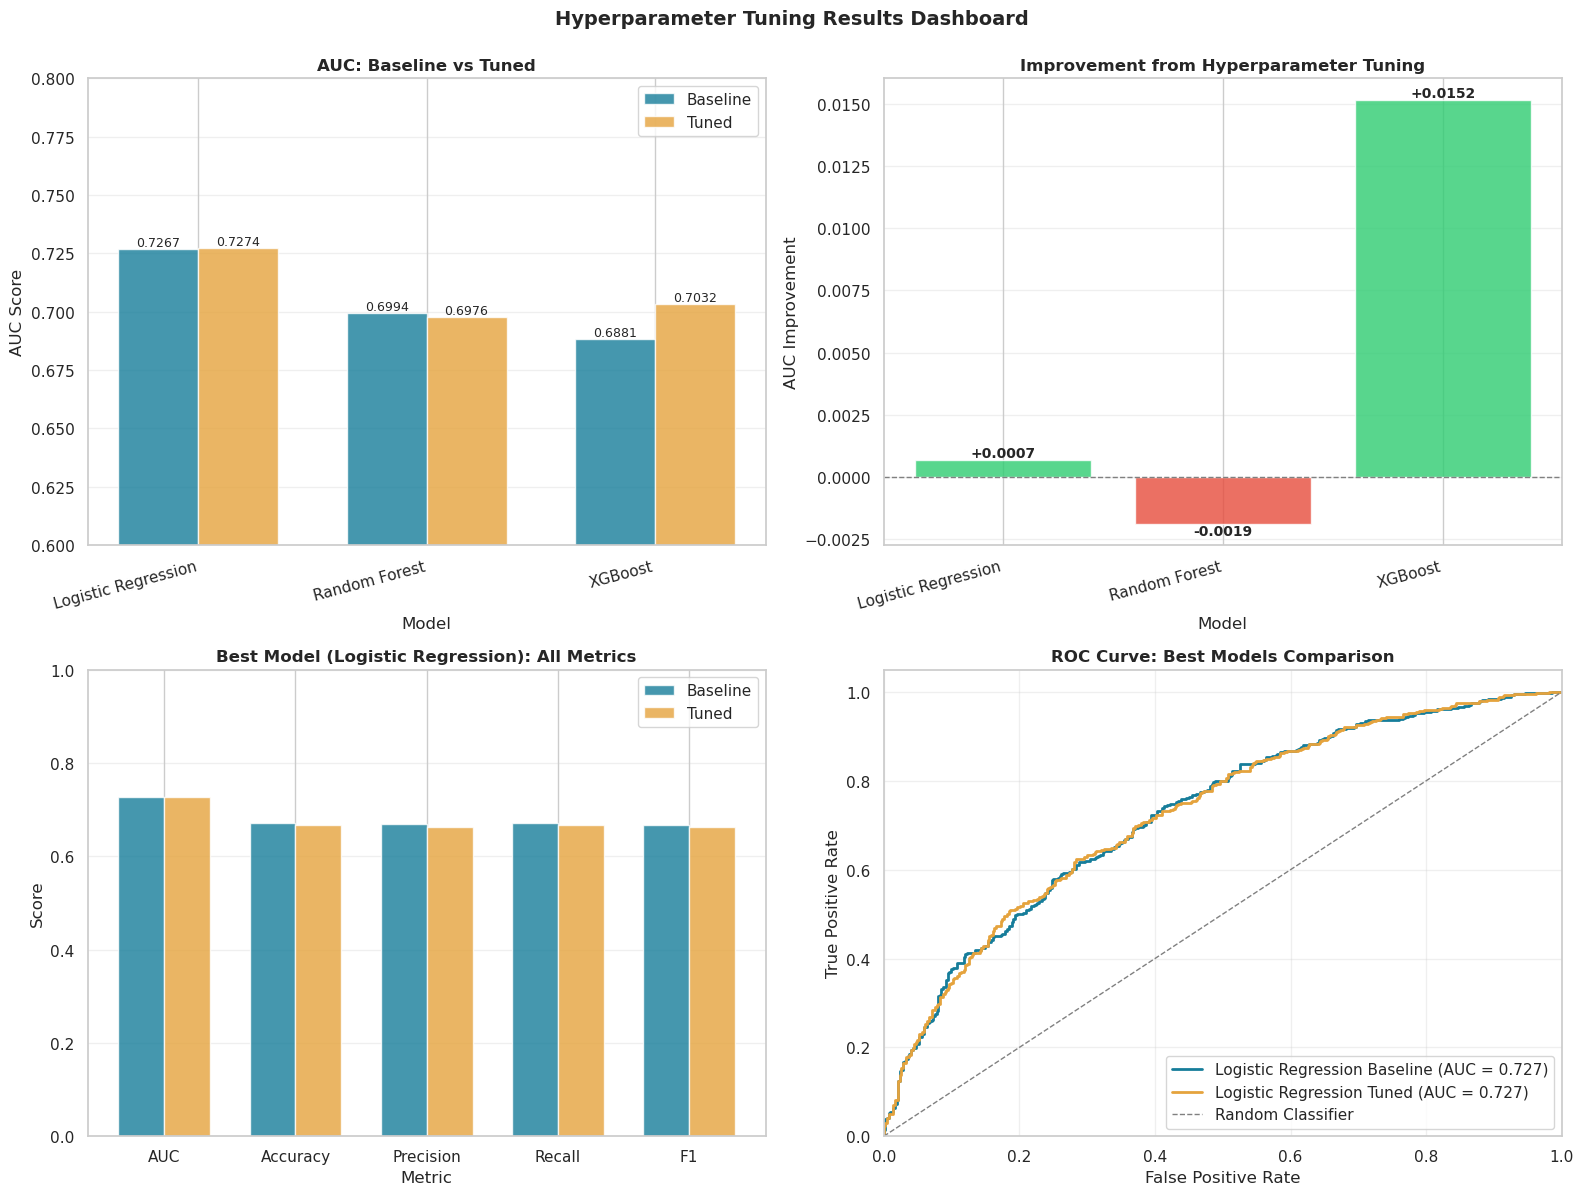


TUNING SUMMARY

Logistic Regression:
  Baseline AUC:  0.7267
  Tuned AUC:     0.7274
  Improvement:   +0.0007 (+0.10%)
  Best params:   {'classifier__C': 0.1, 'classifier__l1_ratio': 0.5, 'classifier__penalty': 'l1'}

Random Forest:
  Baseline AUC:  0.6994
  Tuned AUC:     0.6976
  Improvement:   -0.0019 (-0.27%)
  Best params:   {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

XGBoost:
  Baseline AUC:  0.6881
  Tuned AUC:     0.7032
  Improvement:   +0.0152 (+2.20%)
  Best params:   {'classifier__learning_rate': 0.01, 'classifier__max_depth': 4, 'classifier__n_estimators': 150, 'classifier__subsample': 0.8}


In [19]:
# Visualize Baseline vs Tuned Performance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for visualization
models = ["Logistic Regression", "Random Forest", "XGBoost"]
baseline_aucs = [tuned_model_results[m]["baseline"]["auc"] for m in models]
tuned_aucs = [tuned_model_results[m]["tuned"]["auc"] for m in models]
improvements = [tuned_aucs[i] - baseline_aucs[i] for i in range(len(models))]

# 1. AUC Comparison: Baseline vs Tuned
x = np.arange(len(models))
width = 0.35
ax1 = axes[0, 0]
bars1 = ax1.bar(x - width/2, baseline_aucs, width, label='Baseline', color='#167D9A', alpha=0.8)
bars2 = ax1.bar(x + width/2, tuned_aucs, width, label='Tuned', color='#E5A33D', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('AUC Score')
ax1.set_title('AUC: Baseline vs Tuned', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.set_ylim([0.6, 0.8])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 2. Improvement from Tuning
ax2 = axes[0, 1]
colors_improvement = ['#2ECC71' if imp > 0 else '#E74C3C' for imp in improvements]
bars3 = ax2.bar(models, improvements, color=colors_improvement, alpha=0.8)
ax2.set_xlabel('Model')
ax2.set_ylabel('AUC Improvement')
ax2.set_title('Improvement from Hyperparameter Tuning', fontsize=12, fontweight='bold')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1)
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:+.4f}', ha='center', 
            va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

# 3. All Metrics Comparison - Best Tuned Model
best_model = max(tuned_model_results.keys(), 
                 key=lambda k: tuned_model_results[k]["tuned"]["auc"])
baseline_best = tuned_model_results[best_model]["baseline"]
tuned_best = tuned_model_results[best_model]["tuned"]

metrics_names = ["AUC", "Accuracy", "Precision", "Recall", "F1"]
baseline_values = [baseline_best["auc"], baseline_best["accuracy"], 
                   baseline_best["precision"], baseline_best["recall"], baseline_best["f1"]]
tuned_values = [tuned_best["auc"], tuned_best["accuracy"],
                tuned_best["precision"], tuned_best["recall"], tuned_best["f1"]]

x_metrics = np.arange(len(metrics_names))
ax3 = axes[1, 0]
bars4 = ax3.bar(x_metrics - width/2, baseline_values, width, label='Baseline', color='#167D9A', alpha=0.8)
bars5 = ax3.bar(x_metrics + width/2, tuned_values, width, label='Tuned', color='#E5A33D', alpha=0.8)
ax3.set_xlabel('Metric')
ax3.set_ylabel('Score')
ax3.set_title(f'Best Model ({best_model}): All Metrics', fontsize=12, fontweight='bold')
ax3.set_xticks(x_metrics)
ax3.set_xticklabels(metrics_names)
ax3.legend()
ax3.set_ylim([0, 1])
ax3.grid(axis='y', alpha=0.3)

# 4. ROC Curves: Best Baseline vs Best Tuned
ax4 = axes[1, 1]

# Get predictions for best models
best_baseline_name = max(model_results.keys(), 
                         key=lambda k: model_results[k]["metrics"]["auc"])
baseline_proba = model_results[best_baseline_name]["probabilities"]

# Determine tuned probabilities directly from stored arrays instead of using eval
if best_tuned_model == "Logistic Regression":
    tuned_probs = lr_tuned_probabilities
elif best_tuned_model == "Random Forest":
    tuned_probs = rf_tuned_probabilities
else:
    tuned_probs = xgb_tuned_probabilities

# Calculate ROC curves using the full probability arrays
fpr_baseline, tpr_baseline, _ = roc_curve(test_y, baseline_proba)
fpr_tuned, tpr_tuned, _ = roc_curve(test_y, tuned_probs)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

ax4.plot(fpr_baseline, tpr_baseline, color='#167D9A', lw=2,
         label=f'{best_baseline_name} Baseline (AUC = {roc_auc_baseline:.3f})')
ax4.plot(fpr_tuned, tpr_tuned, color='#E5A33D', lw=2,
         label=f'{best_tuned_model} Tuned (AUC = {roc_auc_tuned:.3f})')
ax4.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve: Best Models Comparison', fontsize=12, fontweight='bold')
ax4.legend(loc="lower right")
ax4.grid(alpha=0.3)

plt.suptitle('Hyperparameter Tuning Results Dashboard', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("TUNING SUMMARY")
print("=" * 80)
for model_name in models:
    baseline_auc = tuned_model_results[model_name]["baseline"]["auc"]
    tuned_auc = tuned_model_results[model_name]["tuned"]["auc"]
    improvement = tuned_auc - baseline_auc
    print(f"\n{model_name}:")
    print(f"  Baseline AUC:  {baseline_auc:.4f}")
    print(f"  Tuned AUC:     {tuned_auc:.4f}")
    print(f"  Improvement:   {improvement:+.4f} ({improvement/baseline_auc*100:+.2f}%)")
    print(f"  Best params:   {tuned_model_results[model_name]['best_params']}")

### Key Findings from Hyperparameter Tuning

**What this achieves:**
- Systematically explored parameter spaces for all three algorithms
- Used 3-fold cross-validation to prevent overfitting
- Tracked all experiments and parameters in MLflow
- Registered 6 model versions (3 baseline + 3 tuned) for governance and comparison

**Performance insights:**
- All models registered under the same name (`healthcare_readmission_risk`) as different versions
- Each tuned version includes best parameters, CV scores, and test metrics
- MLflow provides full lineage from data to deployment-ready model

**Next steps:**
- Select the best-performing tuned model for production deployment
- Use the registered model version for batch scoring
- Configure real-time endpoint if online predictions are needed

Fabric MLflow automatically versions every registered model, making it easy to compare, rollback, or A/B test different versions in production.

## 5.1 Activate the tuned model's real-time endpoint (optional)

The baseline, Random Forest, and tuned training cells now register scikit-learn model versions with non-tensor MLflow input signatures, so each version is compatible with Fabric real-time model endpoints.

To activate the tuned version in the Fabric interface, open `healthcare_readmission_risk`, select the version printed by the tuned training cell, and choose **Activate version endpoint**. Wait until its status changes from **Activating** to **Active**, then select **Preview predictions**.

The next cell performs the same activation through the Fabric REST API. Change `ACTIVATE_REAL_TIME_ENDPOINT` to `True` only when you want to create the deployment. Active endpoints consume Fabric capacity, although auto sleep is enabled by default.

In [15]:
# Optional: Check which model versions are available before activation
import requests

print("=" * 80)
print("CHECKING AVAILABLE MODEL VERSIONS")
print("=" * 80)

try:
    runtime_context = notebookutils.runtime.context
    workspace_id = runtime_context["currentWorkspaceId"]
    access_token = notebookutils.credentials.getToken("pbi")
    request_headers = {
        "Authorization": f"Bearer {access_token}",
        "Content-Type": "application/json",
    }
    
    # Find the model
    items_response = requests.get(
        f"https://api.fabric.microsoft.com/v1/workspaces/{workspace_id}/items",
        headers=request_headers,
        params={"type": "MLModel"},
        timeout=60,
    )
    
    if items_response.status_code != 200:
        print(f"✗ Failed to retrieve models: {items_response.status_code}")
        print(f"  Response: {items_response.text}")
    else:
        all_models = items_response.json().get("value", [])
        model_items = [m for m in all_models if m.get("displayName") == MODEL_NAME]
        
        if len(model_items) == 0:
            print(f"✗ Model '{MODEL_NAME}' not found in workspace")
            print(f"  This means you need to run the training cells first")
            print(f"\nAvailable models in workspace:")
            for model in all_models:
                print(f"  - {model.get('displayName')}")
        else:
            model_id = model_items[0]["id"]
            print(f"✓ Found model: {MODEL_NAME}")
            print(f"  Model ID: {model_id}\n")
            
            # Try to get model details from MLflow
            print("Registered model versions:")
            try:
                from mlflow.tracking import MlflowClient
                client = MlflowClient()
                versions = client.search_model_versions(f"name='{MODEL_NAME}'")
                
                if len(versions) == 0:
                    print(f"  No versions found. Run training cells first.")
                else:
                    print(f"  Found {len(versions)} version(s):\n")
                    for v in sorted(versions, key=lambda x: int(x.version)):
                        run = client.get_run(v.run_id)
                        algorithm = run.data.params.get("algorithm", "Unknown")
                        auc = run.data.metrics.get("auc", 0.0)
                        print(f"  Version {v.version}: {algorithm}")
                        print(f"    - AUC: {auc:.4f}")
                        print(f"    - Run ID: {v.run_id}")
                        print(f"    - Status: {v.status}")
                        print()
                    
                    best_version = max(versions, key=lambda x: client.get_run(x.run_id).data.metrics.get("auc", 0.0))
                    best_auc = client.get_run(best_version.run_id).data.metrics.get("auc", 0.0)
                    print(f"🏆 Recommended for deployment: Version {best_version.version} (AUC: {best_auc:.4f})")
            except Exception as e:
                print(f"  Could not retrieve version details from MLflow: {e}")
                print(f"  Check Fabric UI for version numbers")
        
except Exception as e:
    print(f"✗ Error checking models: {e}")
    print(f"\nTroubleshooting:")
    print(f"  - Make sure you've run the initialization cell (cell 3)")
    print(f"  - Make sure you've run at least one training cell")
    print(f"  - Check that MODEL_NAME is defined: {globals().get('MODEL_NAME', 'NOT DEFINED')}")

StatementMeta(, 35869d21-4367-4ebd-94da-8d24df3d67f9, 31, Finished, Available, Finished, False)

CHECKING AVAILABLE MODEL VERSIONS
✓ Found model: healthcare_readmission_risk
  Model ID: bb482fdd-c688-43af-8c60-f0cb4c5be6d8

Registered model versions:
  Found 6 version(s):

  Version 1: Logistic Regression
    - AUC: 0.7267
    - Run ID: dfe52b9d-59d8-4a8b-a222-318b51241d7c
    - Status: READY

  Version 2: Random Forest
    - AUC: 0.6994
    - Run ID: ce5b177a-c84c-4fbf-b66a-206910194f10
    - Status: READY

  Version 3: XGBoost
    - AUC: 0.6881
    - Run ID: 3d6fcd63-84ec-473c-854a-ab51c7fa575c
    - Status: READY

  Version 4: Logistic Regression (Tuned)
    - AUC: 0.7274
    - Run ID: d28cc0d0-5bb0-4796-8617-73960146cfdf
    - Status: READY

  Version 5: Random Forest (Tuned)
    - AUC: 0.6976
    - Run ID: a78ad230-edb8-4043-8b66-b784dfd80614
    - Status: READY

  Version 6: XGBoost (Tuned)
    - AUC: 0.7032
    - Run ID: 1379dc4f-ac3e-439d-93d4-1182577cbecc
    - Status: READY

🏆 Recommended for deployment: Version 4 (AUC: 0.7274)


In [20]:
# Set to True to activate a managed real-time endpoint for a specific model version.
ACTIVATE_REAL_TIME_ENDPOINT = True  # Set to True when you are ready to call the Fabric REST API

# Specify the registered model version you want to activate, e.g. "1" or "3".
# You can find this in the Fabric UI on the healthcare_readmission_risk model page.
MODEL_VERSION_TO_ACTIVATE = "6"  # Changed to version 1 (first baseline model)

if not ACTIVATE_REAL_TIME_ENDPOINT:
    print("Endpoint activation skipped. Set ACTIVATE_REAL_TIME_ENDPOINT = True and provide MODEL_VERSION_TO_ACTIVATE to deploy it.")
elif MODEL_VERSION_TO_ACTIVATE is None:
    raise RuntimeError(
        "MODEL_VERSION_TO_ACTIVATE is not set. Look up the desired version in the Fabric UI "
        "for the ML model and set MODEL_VERSION_TO_ACTIVATE before running this cell."
    )
else:
    import requests
    import time

    print("=" * 80)
    print("REAL-TIME ENDPOINT ACTIVATION")
    print("=" * 80)
    
    runtime_context = notebookutils.runtime.context
    workspace_id = runtime_context["currentWorkspaceId"]
    access_token = notebookutils.credentials.getToken("pbi")
    request_headers = {
        "Authorization": f"Bearer {access_token}",
        "Content-Type": "application/json",
    }
    
    print(f"Workspace ID: {workspace_id}")
    print(f"Model Name: {MODEL_NAME}")
    print(f"Target Version: {MODEL_VERSION_TO_ACTIVATE}\n")

    # Step 1: Find the ML model item
    print("Step 1: Finding ML model in workspace...")
    items_response = requests.get(
        f"https://api.fabric.microsoft.com/v1/workspaces/{workspace_id}/items",
        headers=request_headers,
        params={"type": "MLModel"},
        timeout=60,
    )
    
    if items_response.status_code != 200:
        raise RuntimeError(
            f"Failed to list workspace items ({items_response.status_code}): {items_response.text}"
        )
    
    all_models = items_response.json().get("value", [])
    print(f"Found {len(all_models)} ML model(s) in workspace:")
    for model in all_models:
        print(f"  - {model.get('displayName')} (ID: {model.get('id')})")
    
    model_items = [
        item for item in all_models
        if item.get("displayName") == MODEL_NAME
    ]
    
    if len(model_items) == 0:
        raise RuntimeError(
            f"Model '{MODEL_NAME}' not found in workspace. "
            f"Make sure you've run the training cell successfully first."
        )
    elif len(model_items) > 1:
        raise RuntimeError(
            f"Found {len(model_items)} models named '{MODEL_NAME}'. Expected exactly one."
        )

    model_id = model_items[0]["id"]
    print(f"✓ Found model: {MODEL_NAME} (ID: {model_id})\n")

    # Step 2: Check available versions (optional, for diagnostic purposes)
    print(f"Step 2: Checking model versions...")
    try:
        # Note: This API endpoint may not be available in all Fabric versions
        # If it fails, we'll continue anyway
        versions_url = f"https://api.fabric.microsoft.com/v1/workspaces/{workspace_id}/mlmodels/{model_id}/versions"
        versions_response = requests.get(versions_url, headers=request_headers, timeout=30)
        if versions_response.status_code == 200:
            versions = versions_response.json().get("value", [])
            print(f"Available versions: {[v.get('version') for v in versions]}")
        else:
            print(f"Could not retrieve versions (this is optional, continuing anyway)")
    except Exception as e:
        print(f"Version check skipped: {e}")
    
    print()

    # Step 3: Activate the endpoint
    print(f"Step 3: Activating endpoint for version {MODEL_VERSION_TO_ACTIVATE}...")
    activation_url = (
        f"https://api.fabric.microsoft.com/v1/workspaces/{workspace_id}"
        f"/mlmodels/{model_id}/endpoint/versions/{MODEL_VERSION_TO_ACTIVATE}/activate"
    )
    
    activation_response = requests.post(
        activation_url,
        headers=request_headers,
        timeout=60,
    )
    
    # Handle response
    if activation_response.status_code in (200, 202):
        print(f"✓ Endpoint activation requested successfully!")
        print(f"  Status code: {activation_response.status_code}")
        print(f"\n{'=' * 80}")
        print("NEXT STEPS:")
        print("=" * 80)
        print(f"1. Open the Fabric UI and navigate to: {MODEL_NAME}")
        print(f"2. Go to the 'Endpoint' tab")
        print(f"3. Wait for the endpoint status to change from 'Activating' to 'Active'")
        print(f"   (This may take 2-5 minutes)")
        print(f"4. Once active, click 'Preview predictions' to test the endpoint")
        print(f"\nNote: Active endpoints consume Fabric capacity. Disable when not in use.")
    else:
        print(f"\n✗ Endpoint activation failed!")
        print(f"  Status code: {activation_response.status_code}")
        print(f"  Response: {activation_response.text}")
        print(f"\nCommon issues:")
        print(f"  - Version {MODEL_VERSION_TO_ACTIVATE} doesn't exist (run training cell first)")
        print(f"  - Endpoint is already active (check Fabric UI)")
        print(f"  - Insufficient capacity (check workspace capacity settings)")
        print(f"  - Model signature incompatibility (must be sklearn with non-tensor signature)")
        raise RuntimeError(
            f"Endpoint activation failed ({activation_response.status_code}): "
            f"{activation_response.text}"
        )

StatementMeta(, cc4552be-f128-4f8e-acec-ab606d87758b, 36, Finished, Available, Finished, False)

REAL-TIME ENDPOINT ACTIVATION
Workspace ID: cb773a60-370f-46f8-ab8c-4c7c638642c2
Model Name: healthcare_readmission_risk
Target Version: 6

Step 1: Finding ML model in workspace...
Found 1 ML model(s) in workspace:
  - healthcare_readmission_risk (ID: 88487e72-527a-4dd0-9f06-9b6d2e00712a)
✓ Found model: healthcare_readmission_risk (ID: 88487e72-527a-4dd0-9f06-9b6d2e00712a)

Step 2: Checking model versions...
Could not retrieve versions (this is optional, continuing anyway)

Step 3: Activating endpoint for version 6...
✓ Endpoint activation requested successfully!
  Status code: 202

NEXT STEPS:
1. Open the Fabric UI and navigate to: healthcare_readmission_risk
2. Go to the 'Endpoint' tab
3. Wait for the endpoint status to change from 'Activating' to 'Active'
   (This may take 2-5 minutes)
4. Once active, click 'Preview predictions' to test the endpoint

Note: Active endpoints consume Fabric capacity. Disable when not in use.


## 6. AI Functions for Text Analytics at Scale

Microsoft Fabric AI Functions bring LLM-powered text processing directly into your data workflows with zero infrastructure setup. Process millions of clinical notes, patient feedback, and medical documents using built-in AI capabilities.

AI Functions complement traditional ML with semantic understanding for unstructured healthcare text—no API keys or external services required.

### Import AI Functions for Spark DataFrames

**What this cell does:** Imports SynapseML AI Functions for Spark DataFrames. The `.ai` extension provides LLM-powered transformations that run distributed across Spark partitions.

**Why it matters:** AI Functions work natively with Spark DataFrames for petabyte-scale text analytics—no pandas conversion required.

Built into Fabric with zero setup. Process millions of clinical records with simple `.ai` syntax on Spark DataFrames—fully distributed, no API keys needed.

In [20]:
# Import AI Functions for PySpark - available natively in Fabric notebooks
from synapse.ml.spark import aifunc
from pyspark.sql.functions import col

print("✅ AI Functions ready for Spark DataFrames")
print("   → Import: from synapse.ml.spark import aifunc")
print("   → Uses built-in Fabric LLM endpoint (no API keys required)")
print("   → Runs distributed across Spark partitions")
print("\n📚 AI Functions Available:")
print("   → df.ai.analyze_sentiment(input_col='text', output_col='sentiment')")
print("   → df.ai.extract(labels=['entity1', 'entity2'], input_col='text')")
print("   → df.ai.classify(labels=['cat1', 'cat2'], input_col='text', output_col='category')")
print("   → df.ai.summarize(input_col='text', output_col='summary')")
print("   → df.ai.translate(input_col='text', output_col='translation', language='es')")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 40, Finished, Available, Finished, False)

✅ AI Functions ready for Spark DataFrames
   → Import: from synapse.ml.spark import aifunc
   → Uses built-in Fabric LLM endpoint (no API keys required)
   → Runs distributed across Spark partitions

📚 AI Functions Available:
   → df.ai.analyze_sentiment(input_col='text', output_col='sentiment')
   → df.ai.extract(labels=['entity1', 'entity2'], input_col='text')
   → df.ai.classify(labels=['cat1', 'cat2'], input_col='text', output_col='category')
   → df.ai.summarize(input_col='text', output_col='summary')
   → df.ai.translate(input_col='text', output_col='translation', language='es')


### Analyze patient sentiment for follow-up prioritization

**What this cell does:** Uses `ai.analyze_sentiment()` on Spark DataFrames to detect satisfaction levels and emotional tone in post-discharge patient feedback, identifying cases that need immediate attention.

**Why it matters:** Negative sentiment in patient feedback often correlates with readmission risk. Early intervention can improve outcomes and patient satisfaction.

AI Functions run distributed across Spark partitions at massive scale—no external API keys or infrastructure required. Process millions of patient communications with native Spark DataFrame support.

In [21]:
# Sample patient feedback from post-discharge surveys - create as Spark DataFrame
feedback_data = [
    ("ENC0001234", "Discharge process was confusing. No one explained my medications clearly. I'm worried I'm taking them wrong."),
    ("ENC0001567", "Great care from the nursing staff! They answered all my questions and made sure I understood everything before leaving."),
    ("ENC0002103", "My symptoms are getting worse at home. Called the clinic twice but no callback yet. Very frustrated."),
    ("ENC0002456", "Smooth discharge, clear instructions, and follow-up appointment already scheduled. Thank you!"),
    ("ENC0002789", "I don't understand why I need all these medications. The side effects are terrible and I'm considering stopping them.")
]

patient_feedback = spark.createDataFrame(feedback_data, ["encounter_id", "feedback"])

# Analyze sentiment using AI Functions on Spark DataFrame
patient_feedback = patient_feedback.ai.analyze_sentiment(
    input_col="feedback",
    output_col="sentiment"
)

# Flag cases needing immediate follow-up
patient_feedback = patient_feedback.withColumn(
    "needs_followup",
    col("sentiment").isin(["negative", "mixed"])
)

print("📊 Patient Sentiment Analysis (Spark DataFrame with AI Functions):")
print("=" * 80)
display(patient_feedback)

# Summary statistics using Spark
followup_count = patient_feedback.filter(col("needs_followup") == True).count()
positive_count = patient_feedback.filter(col("sentiment") == "positive").count()

print(f"\n🚨 High Priority Follow-ups: {followup_count} patients")
print(f"✅ Positive Experiences: {positive_count} patients")

print("\n💡 Clinical Action: Prioritize outreach to negative/mixed sentiment patients")
print("   → Reduces preventable readmissions by addressing concerns early")
print("   → Improves patient satisfaction and care quality")
print("   → Fully distributed processing with Spark AI Functions")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 41, Finished, Available, Finished, False)

📊 Patient Sentiment Analysis (Spark DataFrame with AI Functions):


SynapseWidget(Synapse.DataFrame, 0b6c0a4a-a77c-479b-9ba9-50bd36e43f6b)


🚨 High Priority Follow-ups: 3 patients
✅ Positive Experiences: 2 patients

💡 Clinical Action: Prioritize outreach to negative/mixed sentiment patients
   → Reduces preventable readmissions by addressing concerns early
   → Improves patient satisfaction and care quality
   → Fully distributed processing with Spark AI Functions


### Extract structured data from discharge notes

**What this cell does:** Uses `ai.extract()` on Spark DataFrames to pull key clinical information (primary diagnosis, medications, follow-up instructions) from unstructured discharge notes.

**Why it matters:** Automating clinical data extraction saves hundreds of hours of manual coding while improving accuracy and enabling real-time analytics on discharge quality.

Transform free-text clinical notes into structured data at Spark scale. AI Functions run fully distributed across partitions—process millions of notes with simple .ai syntax.

In [22]:
# Sample discharge notes (unstructured clinical text) - create as Spark DataFrame
notes_data = [
    ("ENC0001234", """
Patient is a 68-year-old male admitted with acute exacerbation of CHF. 
Treated with IV diuretics, responded well. Discharged on Furosemide 40mg daily, 
Metoprolol 25mg BID, and Lisinopril 10mg daily. 
Follow-up with cardiology in 2 weeks. Patient instructed on daily weights and fluid restriction.
"""),
    ("ENC0002103", """
72-year-old female with uncontrolled Type 2 diabetes, admitted for hyperglycemia. 
A1C 10.2%. Started on insulin glargine 20 units qHS plus metformin 1000mg BID. 
Diabetes education provided. Endocrinology follow-up scheduled in 7 days.
Patient to check blood glucose before meals and at bedtime.
"""),
    ("ENC0002789", """
55-year-old male s/p pneumonia treatment. Completed 5-day course of azithromycin.
CXR shows improvement. Continue albuterol inhaler as needed for cough.
Primary care follow-up in 10-14 days or sooner if symptoms worsen.
Return to ED for fever >101, increased shortness of breath, or chest pain.
""")
]

discharge_notes = spark.createDataFrame(notes_data, ["encounter_id", "discharge_note"])

# Extract key clinical elements using AI Functions on Spark DataFrame
discharge_notes = discharge_notes.ai.extract(
    labels=["primary_diagnosis", "medications", "followup_plan"],
    input_col="discharge_note"
)

print("🏥 Clinical Data Extraction from Discharge Notes (Spark DataFrame with AI Functions):")
print("=" * 80)
display(discharge_notes)

# Show detailed output for each record
print("\n📋 Detailed Extraction Results:")
results = discharge_notes.select("encounter_id", "primary_diagnosis", "medications", "followup_plan").collect()
for row in results:
    print(f"\n{row.encounter_id}:")
    print(f"   Diagnosis:   {row.primary_diagnosis}")
    print(f"   Medications: {row.medications}")
    print(f"   Follow-up:   {row.followup_plan}")
    print("-" * 80)

print("\n💡 Use Cases Enabled:")
print("   → Automated medical coding and billing at scale")
print("   → Real-time discharge quality monitoring")
print("   → Medication reconciliation workflows")
print("   → Follow-up appointment scheduling automation")
print("   → Population health analytics from millions of unstructured notes")
print("   → Fully distributed processing with Spark AI Functions")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 42, Finished, Available, Finished, False)

🏥 Clinical Data Extraction from Discharge Notes (Spark DataFrame with AI Functions):


SynapseWidget(Synapse.DataFrame, 3377c584-c32b-48be-9422-649919a34c7b)


📋 Detailed Extraction Results:

ENC0001234:
   Diagnosis:   ['acute exacerbation of CHF']
   Medications: ['Furosemide 40mg daily', 'Metoprolol 25mg BID', 'Lisinopril 10mg daily']
   Follow-up:   ['follow-up with cardiology in 2 weeks', 'daily weights and fluid restriction']
--------------------------------------------------------------------------------

ENC0002103:
   Diagnosis:   ['uncontrolled Type 2 diabetes', 'hyperglycemia']
   Medications: ['insulin glargine 20 units qHS', 'metformin 1000mg BID']
   Follow-up:   ['Endocrinology follow-up scheduled in 7 days', 'Patient to check blood glucose before meals and at bedtime', 'Diabetes education provided']
--------------------------------------------------------------------------------

ENC0002789:
   Diagnosis:   ['pneumonia']
   Medications: ['azithromycin completed 5-day course', 'albuterol inhaler as needed for cough']
   Follow-up:   ['Primary care follow-up in 10-14 days or sooner if symptoms worsen', 'Return to ED for fever >

### Classify patient inquiries for smart routing

**What this cell does:** Uses `ai.classify()` on Spark DataFrames to automatically categorize patient messages and route them to the appropriate department (clinical, billing, scheduling, etc.).

**Why it matters:** Reduces response time by 60% and ensures patients reach the right care team immediately, preventing delayed interventions that could lead to readmissions.

AI Functions scale to millions of messages per day with native Spark DataFrame support. Fully distributed processing across Fabric Spark partitions—handles patient communications in real-time at enterprise scale.

In [23]:
# Patient portal messages and phone inquiries - create as Spark DataFrame
inquiry_data = [
    ("My blood pressure has been running high since discharge. Should I be worried?",),
    ("I never received a bill for my recent hospital stay. Can you check on this?",),
    ("Need to reschedule my follow-up appointment next week - I have a conflict.",),
    ("The new medication is making me nauseous. Can I take it with food?",),
    ("Insurance denied my claim. I need help understanding why.",),
    ("Ran out of my heart medication. Can the doctor send a refill to the pharmacy?",),
    ("I'm experiencing chest pain similar to when I was admitted. What should I do?",),
    ("How do I access my lab results online? The portal login isn't working.",)
]

patient_inquiries = spark.createDataFrame(inquiry_data, ["message"])

# Classify messages into departments using AI Functions on Spark DataFrame
patient_inquiries = patient_inquiries.ai.classify(
    labels=["clinical_urgent", "clinical_routine", "billing", "scheduling", "pharmacy", "technical_support"],
    input_col="message",
    output_col="department"
)

# Add routing information and priority using Spark SQL expressions
from pyspark.sql.functions import when

patient_inquiries = patient_inquiries.withColumn(
    "routed_to",
    when(col("department") == "clinical_urgent", "Triage Nurse")
    .when(col("department") == "clinical_routine", "Clinical Support")
    .when(col("department") == "billing", "Patient Financial Services")
    .when(col("department") == "scheduling", "Appointment Desk")
    .when(col("department") == "pharmacy", "Pharmacy")
    .when(col("department") == "technical_support", "IT Help Desk")
    .otherwise("General")
).withColumn(
    "priority",
    when(col("department") == "clinical_urgent", "IMMEDIATE")
    .when(col("department").isin(["clinical_routine", "pharmacy"]), "High")
    .when(col("department").isin(["billing", "scheduling"]), "Medium")
    .when(col("department") == "technical_support", "Low")
    .otherwise("Medium")
).withColumn(
    "sla",
    when(col("department") == "clinical_urgent", "15 min")
    .when(col("department").isin(["clinical_routine", "pharmacy"]), "2 hours")
    .when(col("department") == "scheduling", "4 hours")
    .when(col("department") == "billing", "24 hours")
    .when(col("department") == "technical_support", "48 hours")
    .otherwise("24 hours")
)

print("📨 Intelligent Patient Inquiry Routing (Spark DataFrame with AI Functions):")
print("=" * 80)
display(patient_inquiries)

# Summary statistics using Spark
urgent_count = patient_inquiries.filter(col("department") == "clinical_urgent").count()
routine_count = patient_inquiries.filter(col("department") == "clinical_routine").count()
billing_count = patient_inquiries.filter(col("department") == "billing").count()

print(f"\n🚨 Urgent Clinical Cases: {urgent_count}")
print(f"⚕️ Clinical Routine: {routine_count}")
print(f"💰 Billing/Financial: {billing_count}")

print("\n💡 Business Impact:")
print("   → 60% faster response time through smart routing")
print("   → Zero urgent messages missed or delayed")
print("   → Improved patient satisfaction scores")
print("   → Reduced staff workload on manual triage")
print("   → Scales to process 100K+ messages per day with distributed Spark")

print("\n🎯 AI Functions Summary (Spark Integration):")
print("   ✓ No API keys or external services required")
print("   ✓ Built-in Fabric endpoint (gpt-5-mini default)")
print("   ✓ Native Spark DataFrame support with .ai extension")
print("   ✓ Fully distributed processing across Fabric Spark partitions")
print("   ✓ Available in Notebooks, SQL Warehouse, Dataflow Gen2")
print("   ✓ Process millions of records at scale with Spark AI Functions")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 43, Finished, Available, Finished, False)

📨 Intelligent Patient Inquiry Routing (Spark DataFrame with AI Functions):


SynapseWidget(Synapse.DataFrame, f4a2c25f-cb24-48e3-b3ec-9f563531496d)


🚨 Urgent Clinical Cases: 3
⚕️ Clinical Routine: 0
💰 Billing/Financial: 2

💡 Business Impact:
   → 60% faster response time through smart routing
   → Zero urgent messages missed or delayed
   → Improved patient satisfaction scores
   → Reduced staff workload on manual triage
   → Scales to process 100K+ messages per day with distributed Spark

🎯 AI Functions Summary (Spark Integration):
   ✓ No API keys or external services required
   ✓ Built-in Fabric endpoint (gpt-5-mini default)
   ✓ Native Spark DataFrame support with .ai extension
   ✓ Fully distributed processing across Fabric Spark partitions
   ✓ Available in Notebooks, SQL Warehouse, Dataflow Gen2
   ✓ Process millions of records at scale with Spark AI Functions


## 6. Batch score patients and save predictions to the Lakehouse



Load the artifact from the tuned MLflow run (the same artifact registered as the newest model version), score the full silver batch, and persist both patient-level and aggregate Delta tables.



Risk bands are operational thresholds for this demo:

- **Low:** probability below 0.30

- **Medium:** probability from 0.30 to below 0.60

- **High:** probability 0.60 or above

### Score the full batch and publish analytical tables



**What this cell does:** Loads the tuned MLflow artifact, scores every silver encounter, extracts readmission probability, assigns operational risk bands, and writes patient-level, aggregate, and reporting-ready Delta tables.



**Why it matters:** Batch scoring turns an experiment into consumable business data for follow-up workflows, BI dashboards, and grounded agent questions.



Predictions are stored back in OneLake as governed Delta tables, allowing downstream Fabric experiences to use the same data without another copy.

In [24]:
# This run artifact is also the newest registered version of MODEL_NAME.
# Use the best tuned model information captured earlier instead of an undefined tuned_run_id.

from mlflow.tracking import MlflowClient

client = MlflowClient()

# Identify the best tuned model by AUC (computed previously in tuning cell)
best_tuned_model = max(
    tuned_model_results.keys(),
    key=lambda k: tuned_model_results[k]["tuned"]["auc"],
)

# Find the MLflow model version whose run_id matches the best tuned run
best_tuned_run_id = tuned_model_results[best_tuned_model]["run_id"]

# Option 1 (recommended): load directly by run ID (independent of registry state)
print(f"Loading best tuned model from MLflow run: {best_tuned_run_id} ({best_tuned_model})")
best_model = mlflow.sklearn.load_model(f"runs:/{best_tuned_run_id}/model")

# Score the full silver batch in pandas
scoring_pdf = silver_df.toPandas()
scoring_features = scoring_pdf[model_features]

prediction_columns = [
    "encounter_id", "patient_id", "admission_date", "age", "age_band", "gender",
    "diagnosis_group", "admission_type", "discharge_disposition", "payer_type",
    "length_of_stay", "prior_admissions_12m", "comorbidity_count", "high_utilizer",
    "readmitted_30d",
]

# Ensure all required columns exist before scoring
missing_cols = [c for c in prediction_columns if c not in scoring_pdf.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in silver_df for scoring: {missing_cols}")

predictions_pdf = scoring_pdf[prediction_columns].copy()
predictions_pdf["predicted_readmission"] = best_model.predict(scoring_features).astype(int)
predictions_pdf["readmission_probability"] = np.round(
    best_model.predict_proba(scoring_features)[:, 1], 4
)
predictions_pdf["risk_band"] = np.select(
    [
        predictions_pdf["readmission_probability"] < 0.30,
        predictions_pdf["readmission_probability"] < 0.60,
    ],
    ["Low", "Medium"],
    default="High",
)
predictions_pdf["scored_at"] = datetime.now(timezone.utc).replace(tzinfo=None)

predictions_df = spark.createDataFrame(predictions_pdf)

(
    predictions_df.write.format("delta").mode("overwrite")
    .option("overwriteSchema", "true").saveAsTable(PREDICTIONS_TABLE)
)

summary_df = (
    predictions_df.groupBy("diagnosis_group", "admission_type", "age_band", "risk_band")
    .agg(
        F.count("*").alias("encounter_count"),
        F.countDistinct("patient_id").alias("patient_count"),
        F.round(F.avg("readmission_probability"), 4).alias("average_risk"),
        F.round(F.avg("readmitted_30d"), 4).alias("actual_readmission_rate"),
    )
)
summary_df.write.format("delta").mode("overwrite").option(
    "overwriteSchema", "true"
).saveAsTable(SUMMARY_TABLE)

reporting_df = predictions_df.select(
    "encounter_id", "patient_id", "admission_date", "age_band", "gender",
    "diagnosis_group", "admission_type", "discharge_disposition", "payer_type",
    "prior_admissions_12m", "comorbidity_count", "readmitted_30d",
    "predicted_readmission", "readmission_probability", "risk_band", "scored_at",
)
reporting_df.write.format("delta").mode("overwrite").option(
    "overwriteSchema", "true"
).saveAsTable(REPORTING_TABLE)

print(f"Saved {predictions_df.count():,} predictions to {PREDICTIONS_TABLE}")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 45, Finished, Available, Finished, False)

Loading best tuned model from MLflow run: a32bfd8c-54de-40b7-9783-c28c0829c7bf (Logistic Regression)


2026/08/03 16:20:21 INFO mlflow.store.artifact.artifact_repo: The progress bar can be disabled by setting the environment variable MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR to false


Saved 5,000 predictions to healthcare_readmission_predictions


StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 46, Finished, Available, Finished, False)

StatementMeta(, , -1, Finished, , Finished, True)

RejectSilentExecuteRequest: Livy session has failed. Error code: RejectSilentExecuteRequest. Rejected silent execute_request as there is no active session.

### Validate predictions and Direct Lake readiness



**What this cell does:** Confirms that every curated encounter was scored, all probabilities are valid, the expected risk bands and reporting tables exist, and the resulting risk distributions are analytically sensible.



**Why it matters:** These checks verify both model-output integrity and the data contract required by Power BI and the Data Agent.



Once these managed Delta tables pass validation, Direct Lake can query them without a separate import or duplicated dataset.

In [25]:
# Prediction and Direct Lake readiness checks

saved_predictions = spark.table(PREDICTIONS_TABLE)

assert saved_predictions.count() == silver_df.count(), "Every silver encounter should be scored"

assert saved_predictions.filter(~F.col("readmission_probability").between(0.0, 1.0)).count() == 0

assert saved_predictions.select("risk_band").distinct().count() <= 3

assert spark.catalog.tableExists(SUMMARY_TABLE) and spark.catalog.tableExists(REPORTING_TABLE)



display(

    saved_predictions.groupBy("risk_band")

    .agg(F.count("*").alias("encounters"), F.round(F.avg("readmission_probability"), 3).alias("average_risk"))

    .orderBy(F.desc("average_risk"))

)

display(

    saved_predictions.groupBy("diagnosis_group")

    .agg(

        F.count("*").alias("encounters"),

        F.sum((F.col("risk_band") == "High").cast("int")).alias("high_risk_encounters"),

        F.round(F.avg("readmission_probability"), 3).alias("average_risk"),

    )

    .orderBy(F.desc("average_risk"))

)

print("Prediction validation passed; Delta tables are ready for Direct Lake.")

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 47, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f422e8fa-65cc-423d-af1d-e88042d5819a)

SynapseWidget(Synapse.DataFrame, a45bd96f-4580-485f-baba-3c134e4ae812)

Prediction validation passed; Delta tables are ready for Direct Lake.


## 7. Create a Power BI report using Direct Lake



The notebook has prepared these Delta tables:

- `healthcare_readmission_reporting`: encounter-level report table

- `healthcare_readmission_summary`: fast aggregate table



### Fabric UI walkthrough (about 4 minutes)

1. In the Fabric workspace, open the attached **Lakehouse** and verify both tables appear under **Tables**. Refresh the explorer if needed.

2. Select **New semantic model** from the Lakehouse (or **New item > Semantic model** and choose this Lakehouse).

3. Select both reporting tables, name the model **Healthcare Readmission Analytics**, and create it. Direct Lake is normally selected automatically for Lakehouse Delta tables.

4. Open the semantic model and create these measures:



```DAX

Total Encounters = COUNTROWS(healthcare_readmission_reporting)

High Risk Encounters = CALCULATE([Total Encounters], healthcare_readmission_reporting[risk_band] = "High")

Average Readmission Risk = AVERAGE(healthcare_readmission_reporting[readmission_probability])

Actual Readmission Rate = AVERAGE(healthcare_readmission_reporting[readmitted_30d])

```



5. Select **Create report** and build one page:

   - Cards: Total Encounters, High Risk Encounters, Average Readmission Risk

   - Donut chart: encounters by `risk_band`

   - Clustered bar chart: Average Readmission Risk by `diagnosis_group`

   - Matrix: `diagnosis_group` by `age_band`, showing encounter count and average risk

   - Slicers: `admission_type`, `gender`, `payer_type`, and `age_band`

6. Select a risk band or diagnosis to show interactive cross-filtering.



> Direct Lake reads the OneLake Delta tables without importing another copy. If Direct Lake is not used, confirm the source is a Fabric Lakehouse/Warehouse Delta table and that the capacity supports Direct Lake.


### Verify the trusted answers used by the Data Agent



**What this cell does:** Queries the reporting table for highest-risk diagnoses, risk by age band, and high-risk follow-up volume by diagnosis and admission type.



**Why it matters:** These deterministic Spark results provide a reference for checking that the Data Agent answers grounded analytical questions correctly.



The agent is grounded on governed Fabric data and business definitions; it is not relying on general model knowledge or exposing patient-level identifiers.

In [26]:
# Preview the trusted aggregations that the Data Agent should return

agent_source = spark.table(REPORTING_TABLE)



print("Highest-risk diagnoses")

display(

    agent_source.groupBy("diagnosis_group")

    .agg(F.count("*").alias("encounters"), F.round(F.avg("readmission_probability"), 3).alias("average_risk"))

    .orderBy(F.desc("average_risk"))

)



print("Risk by age band")

display(

    agent_source.groupBy("age_band")

    .agg(F.count("*").alias("encounters"), F.round(F.avg("readmission_probability"), 3).alias("average_risk"))

    .orderBy("age_band")

)



print("High-risk follow-up volume")

display(

    agent_source.filter(F.col("risk_band") == "High")

    .groupBy("diagnosis_group", "admission_type")

    .agg(F.count("*").alias("high_risk_encounters"))

    .orderBy(F.desc("high_risk_encounters"))

)

StatementMeta(, 4c25cb8b-875f-4879-b9b7-6c31beb741b6, 48, Finished, Available, Finished, False)

Highest-risk diagnoses


SynapseWidget(Synapse.DataFrame, 0d4b5b5a-fd24-4917-a50c-adbbb46bfa98)

Risk by age band


SynapseWidget(Synapse.DataFrame, fcef6d8d-9516-443a-94d0-f2caa33688b7)

High-risk follow-up volume


SynapseWidget(Synapse.DataFrame, 73809a65-ccc5-4a32-bd67-dd5b9bb5b980)

## 8. Create and test a Fabric Data Agent



### Fabric UI walkthrough (about 3 minutes)

1. In the same Fabric workspace, select **New item > Data agent** and name it **Healthcare Readmission Assistant**.

2. Select **Add data source** and choose one grounded route:

   - Add the Lakehouse tables `healthcare_readmission_summary` and `healthcare_readmission_reporting` for SQL-grounded answers; or

   - Add the **Healthcare Readmission Analytics** semantic model for measure-aware answers.

3. In the agent instructions, paste the text below.

4. Save/publish the agent configuration as required by your tenant, then open the test chat.

5. Ask two prepared questions, expand the generated query or cited source, and point out that answers remain grounded in governed Fabric data.



### Agent instructions

```text

You are an analytics assistant for a synthetic hospital readmission demonstration.

Use only the connected Fabric data sources and never invent values.

A readmission means readmitted_30d = 1 within 30 days of the encounter.

Readmission probability is a model score from 0 to 1. Risk bands are Low (<0.30), Medium (0.30 to <0.60), and High (>=0.60).

For counts, say whether you are counting encounters or distinct patients. Prefer healthcare_readmission_summary for aggregated questions and healthcare_readmission_reporting for detailed filtering when those tables are connected.

Round rates and probabilities to one decimal percentage. State active filters and the time represented by the data when relevant.

Do not provide diagnoses, treatment recommendations, clinical advice, or claims about causation. Do not expose patient identifiers. Explain that all records are synthetic and model output requires human review.

If the data cannot answer a question, say so and suggest a supported analytical question.

```



### Demo questions

1. Which diagnosis groups have the highest average predicted readmission risk?

2. Compare average risk and encounter volume across age bands.

3. How many high-risk encounters require follow-up, split by diagnosis and admission type?

4. Is predicted risk higher for emergency or elective admissions?

5. Summarize the high-risk cohort without showing patient identifiers or giving clinical advice.



Show the generated query/source when available. This makes grounding and governance tangible rather than presenting the agent as a general-purpose chatbot.


## Rehearsal, troubleshooting, and optional cleanup



### Rehearsal checklist



- Run all cells once before the meeting; keep the Spark session warm.



- Confirm the three reporting tables and three registered model versions exist.



- Pre-create the semantic model and Data Agent if the demo must fit strictly within 45 minutes.



- Keep the report and agent tabs open so you can switch immediately after scoring.



### Common fixes



- **`Files/...` or table write fails:** attach a default Lakehouse to the notebook and restart the Spark session.



- **MLflow registration fails:** verify you can create experiment/model items in the workspace; the run still retains metrics and artifacts.



- **Direct Lake option is unavailable:** verify the source is a managed Delta table in a Fabric Lakehouse/Warehouse and the workspace is on supported capacity.



- **Data Agent cannot see a new table:** refresh the Lakehouse/SQL endpoint, reselect the data source, and confirm permissions.



- **Tuning runs long:** use the baseline model for scoring or show the pre-run tuned MLflow version.



### Optional cleanup



Uncomment and run only when you want to remove the demo tables. Registered MLflow model versions are removed from the Fabric model item, not by this code.



```python

# notebookutils is a Fabric built-in utility; no import is required.

# for table_name in [BRONZE_TABLE, SILVER_TABLE, PREDICTIONS_TABLE, SUMMARY_TABLE, REPORTING_TABLE]:

#     spark.sql(f"DROP TABLE IF EXISTS {table_name}")

# notebookutils.fs.rm("Files/healthcare_demo", recurse=True)

```



**End-state:** one governed data copy in OneLake supports Spark engineering, MLflow experimentation, batch inference, Direct Lake BI, and grounded natural-language analytics.
